# Debug

### Colony Simulation pq emission Debug

#### Debug Steps

**Problem Description**

I am using `ecoli_engine_process.py` for colony simulation under baseline conditions. While I can successfully save snapshots of the colony state, I continuously encounter errors when trying to emit Parquet files for single-cell data. I wonder if anyone has successfully done this without an online emitter?

The errors and attempted debugging steps are shown below. I noticed the implemented antibiotic simulation uses an online database as the emitter, so I included observations about that in the last section.

It could be a different underlying reason why my simulation failed, and I would appreciate any insights or suggestions!

**Environment**
- vEcoli commit: (current main branch)
- Python 3.12
- Config: `spatial.json` inheritance with `"emitter": "parquet"`

**Goal**

Resume a colony simulation from a saved JSON state file (`baseline_2gen_seed_0_colony_t6000.json`) and output to Parquet files.

**My Configuration File** / `configs/colony_baseline_test2.json`:
```json
{
    "inherit_from": ["spatial.json"],
    "description": "Test2: read from trial1, run for another generation, save parquet per cell, save final state",
    "initial_colony_file": "baseline_2gen_seed_0_colony_t6000",

    "seed": 0,
    "sim_data_path": "out/all_media_conditions1/parca/kb/simData.cPickle",
    
    "emitter": "parquet",
    "emitter_arg": {
        "out_dir": "out/colony_runs/baseline_3rd_gen_seed_0"
    },
    "emit_config": false,

    "max_duration": 9000,
    
    "save": true,
    "save_times": [9000],
    "colony_save_prefix": "baseline_3rd_gen",
    
    "parallel": false,
    
    "engine_process_reports": [
        ["boundary"],
        ["bulk"],
        ["listeners"],
        ["environment", "exchange"]
    ]
}
```

---

**Issue 1: `NumpyRandomStateSerializer` Serialization/Deserialization Mismatch**

- Command:
```bash
python ecoli/experiments/ecoli_engine_process.py --config configs/colony_baseline_test2.json
```

- Error:
```
Traceback (most recent call last):
  File "ecoli/experiments/ecoli_engine_process.py", line 526, in <module>
    run_simulation(config)
  File "ecoli/experiments/ecoli_engine_process.py", line 389, in run_simulation
    initial_state = get_state_from_file(...)
  File "ecoli/library/json_state.py", line 168, in get_state_from_file
    return json.loads(f.read(), object_hook=custom_decoder)
  File "ecoli/library/serialize.py", line 83, in deserialize
    data = orjson.loads(data)
orjson.JSONDecodeError: unexpected character: line 1 column 1 (char 0)
```

- Possible Root Cause:
  - `serialize()` at line 70-72 appears to output Python tuple format: `('MT19937', [...])`
  - `deserialize()` at line 82 uses `orjson.loads()` which expects JSON array format: `["MT19937", [...]]`

- File: `ecoli/library/serialize.py`

- Original code (lines 78-85):
```python
def deserialize(self, data):
    matched_regex = self.regex_for_serialized.fullmatch(data)
    if matched_regex:
        data = matched_regex.group(1)
    data = orjson.loads(data)
    rng = np.random.RandomState()
    rng.set_state(data)
    return rng
```

- Attempted Fix: Replace `orjson.loads()` with `ast.literal_eval()` to handle Python tuple format:
```python
def deserialize(self, data):
    import ast
    matched_regex = self.regex_for_serialized.fullmatch(data)
    if matched_regex:
        data = matched_regex.group(1)
    if data.startswith("("):
        data = ast.literal_eval(data)
    else:
        data = orjson.loads(data)
    rng = np.random.RandomState()
    rng.set_state(tuple(data))
    return rng
```

---

**Issue 2: Parquet Emitter Cannot Handle `pint.Quantity` in Config Metadata**

- Error (after attempting to fix Issue 1):
```
Traceback (most recent call last):
  File "ecoli/library/parquet_emitter.py", line 963, in emit
    v = np.asarray(v, dtype=np_dtype(v, k))
  File "ecoli/library/parquet_emitter.py", line 706, in np_dtype
    raise ValueError(f"{field_name} has unsupported type {type(val)}.")
ValueError: spatial_environment_config__multibody__bounds has unsupported type <class 'pint.Quantity'>.

During handling of the above exception, another exception occurred:
  File "ecoli/library/parquet_emitter.py", line 967, in emit
    v = pl.Series([v])
TypeError: not yet implemented: Nested object types
```

- Possible Root Cause:
  - `spatial.json` contains `pint.Quantity` values (e.g., `"!units[50 micrometer]"`)
  - `np_dtype()` doesn't appear to handle `pint.Quantity`, and falls back to Polars
  - `pl.Series([v])` also seems unable to handle `pint.Quantity` objects

- File: `ecoli/library/parquet_emitter.py`

- Original code (line 967):
```python
v = pl.Series([v])
```

- Attempted Fix: Convert unsupported types to string:
```python
v = pl.Series([str(v)])
```

---

**Issue 3: `emit_config` Setting Not Passed to Engine**

- Note: Even after the `str(v)` fix, I attempted to disable config emission via JSON config `"emit_config": false`, but it appeared to have no effect.

- Possible Root Cause: `ecoli_engine_process.py` does not seem to pass the `emit_config` parameter to the Engine constructor.

- File: `ecoli/experiments/ecoli_engine_process.py`

- Original code (around line 465):
```python
engine = Engine(
    processes=composite.processes,
    topology=composite.topology,
    initial_state=initial_state,
    experiment_id=experiment_id,
    emitter=emitter_config,
    progress_bar=config["progress_bar"],
    metadata=metadata,
    profile=config["profile"],
    initial_global_time=config.get("start_time", 0.0),
)
```

- Attempted Fix: Add `emit_config` parameter:
```python
engine = Engine(
    ...
    initial_global_time=config.get("start_time", 0.0),
    emit_config=config.get("emit_config", False),
)
```

---

**Issue 4: Parquet Emitter Assumes `agents` Key in Data Structure**

- Error (after attempting to fix Issues 1-3):
```
Traceback (most recent call last):
  File "ecoli/experiments/ecoli_engine_process.py", line 485, in run_simulation
    colony_save_states(engine, config)
  File "ecoli/experiments/ecoli_engine_process.py", line 255, in colony_save_states
    engine.update(time_to_next_save)
  ...
  File "ecoli/processes/engine_process.py", line 505, in next_update
    self.emitter.emit(emit_config)
  File "ecoli/library/parquet_emitter.py", line 1007, in emit
    if len(data["data"]["agents"]) > 1:
KeyError: 'agents'
```

- Possible Root Cause:
  - `ParquetEmitter.emit()` appears to expect a `data["data"]["agents"]` structure (outer simulation)
  - EngineProcess inner emitter seems to send cell data directly without the `agents` wrapper
  - The inner emitter is configured via `inner_emitter` in the EngineProcess config

- File: `ecoli/library/parquet_emitter.py` (line 1007)

- Potential Fix (not tested): Add check for both data structures:
```python
if "agents" in data["data"]:
    if len(data["data"]["agents"]) > 1:
        return
    for agent_data in data["data"]["agents"].values():
        ...
else:
    # Inner simulation from EngineProcess
    agent_data = data["data"].copy()
    ...
```

---

**Observations on Implemented Antibiotic Simulation**

The `tet_amp_sim.py` uses a different configuration that appears to avoid these issues:

```python
# From configs/cloud.json (inherited by antibiotics.json)
{
    "emitter": "database",  # MongoDB, not Parquet
    "emitter_arg": {"host": "10.138.0.75:27017", "emit_limit": 4100000}
}
```

- **MongoDB** can handle arbitrary Python objects including `pint.Quantity`
- No JSON serialization issues with `NumpyRandomState`
- No `agents` key structure assumptions

---

**Summary Table**

| Issue | File | Line | Status |
|-------|------|------|--------|
| 1. RandomState serialize/deserialize mismatch | `serialize.py` | 78-85 | Attempted fix with `ast.literal_eval()` |
| 2. `pint.Quantity` not supported | `parquet_emitter.py` | 967 | Attempted fix with `str(v)` |
| 3. `emit_config` not passed to Engine | `ecoli_engine_process.py` | ~470 | Attempted fix by adding parameter |
| 4. Missing `agents` key handling | `parquet_emitter.py` | 1007 | **UNRESOLVED** |

**Workaround**

Setting `"inner_emitter": "null"` in config may disable Parquet emission from inner EngineProcess simulations while the outer emitter should still work for colony-level data. (Not fully tested.)

#### Model Inner Structure Investigated

**Summary: Emitter System Investigation**

We traced the emitter initialization flow through vivarium-core:

- **`vivarium/core/engine.py`**: The `Engine` class constructor accepts `emitter` (string name or dict config) and `emit_config` (bool, default `False`). Calls `get_emitter()` to instantiate the emitter.

- **`vivarium/core/emitter.py`**: Contains `emitter_registry` (a `Registry` object) and `get_emitter()` function. Built-in emitters: `"timeseries"` (RAM), `"database"` (MongoDB), `"null"` (disabled). The `get_emitter()` function looks up the emitter class by name from the registry.

- **`ecoli/__init__.py`** (line 39): Registers vEcoli's custom Parquet emitter: `emitter_registry.register("parquet", ParquetEmitter)`. This makes `"emitter": "parquet"` available in config files.

Key insight: The antibiotic simulation uses `"database"` (MongoDB) which handles arbitrary Python objects natively, avoiding the serialization issues we encountered with the Parquet emitter.

### Further Debug

Debug for lower emission rate: The ecoli_master_engine has been added with emit_step and the parquet_emitter has been add boundary conditon with zero-shaped arrays.

Therefore, the 3rd gen simulation is rerun to check if these changes will make a difference in pq emission during colony simulation.

# Readings

## Env Factors

### Load data

In [2]:
import json

with open('/user/home/il22158/work/vEcoli/data/baseline_2gen_seed_0_colony_t6000.json', 'r') as f:
    data = json.load(f)

agents = data['agents']
agent_ids = sorted(agents.keys())

# Get all unique keys (categories) across all agents
all_keys = set()
for agent in agents.values():
    all_keys.update(agent.keys())

print("Agent names (IDs):")
print(agent_ids)
print("\nUnique categories (keys):")
print(sorted(all_keys))

Agent names (IDs):
['000', '001', '010', '011']

Unique categories (keys):
['allocate', 'allocator_rng', 'boundary', 'bulk', 'bulk_dtypes', 'cytoplasm', 'divide', 'division_threshold', 'division_trigger', 'environment', 'global_time', 'listeners', 'next_update_time', 'periplasm', 'process_state', 'request', 'timeline', 'timestep', 'unique', 'unique_dtypes']


In [3]:
# Show dtype and preview for each category for the first agent
sample_agent = agents[agent_ids[0]]
print(f"\n--- Data preview for agent '{agent_ids[0]}' ---")
for key in sorted(all_keys):
    value = sample_agent.get(key, None)
    print(f"\nCategory: '{key}'")
    print(f"Type: {type(value)}")
    if isinstance(value, dict):
        subkeys = sorted(value.keys())
        print(f"Exclusive subcategories: {subkeys}")
    elif isinstance(value, list):
        print(f"Length: {len(value)}")
        print(f"First 3 entries: {value[:3]}")
    else:
        print(f"Value: {value}")


--- Data preview for agent '000' ---

Category: 'allocate'
Type: <class 'dict'>
Exclusive subcategories: ['ecoli-chromosome-replication', 'ecoli-complexation', 'ecoli-equilibrium', 'ecoli-polypeptide-elongation', 'ecoli-polypeptide-initiation', 'ecoli-protein-degradation', 'ecoli-rna-degradation', 'ecoli-rna-maturation', 'ecoli-transcript-elongation', 'ecoli-transcript-initiation', 'ecoli-two-component-system']

Category: 'allocator_rng'
Type: <class 'str'>
Value: !RandomStateSerializer[('MT19937', [1032081874, 3921390043, 1775671866, 3050400842, 613040236, 3120117409, 313685, 4009028496, 3451362311, 1611313565, 1216908950, 1280315550, 2094310855, 486956331, 2341192965, 835091154, 3469137642, 701790974, 3147330632, 4284971845, 196483250, 3605856335, 2998782482, 1551059047, 772023894, 3028362759, 2054139155, 1697376821, 3256171168, 1295408492, 409809183, 2117531738, 1695919879, 3445769087, 3326475278, 232416836, 3552623864, 3205095980, 1077074508, 4278080904, 2968265471, 3704500986, 38

In ''bulk'', ''submass'' refers to the contribution of a chemical to a specific cellular mass compartment. The bulk_dtypes field lists submass types such as rRNA_submass, tRNA_submass, mRNA_submass, miscRNA_submass, nonspecific_RNA_submass, protein_submass, metabolite_submass, water_submass, DNA_submass.

For each chemical, only one submass field is typically non-zero, corresponding to the compartment that chemical belongs to. For example:

If the chemical is a protein, only protein_submass will be non-zero.
If it’s a metabolite, only metabolite_submass will be non-zero.
If it’s an rRNA, only rRNA_submass will be non-zero.

In [4]:
# Preview exclusive lists for both 'exchange' and 'media_id' subcategories across all agents
exchange_keys = set()
media_ids = set()
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    exchange_keys.update(exchange.keys())
    media_ids.add(env.get('media_id', None))

print("Exclusive list of all exchange chemicals across agents:")
print(sorted(exchange_keys))
print("\nExclusive list of all media_id values across agents:")
print(sorted(media_ids))


Exclusive list of all exchange chemicals across agents:
['4FE-4S', '5-Deoxy-D-Ribofuranose', 'ACET', 'AMMONIUM', 'ARABINOSE', 'ARG', 'ASN', 'BETAINE', 'BUTANAL', 'CA+2', 'CARBON-DIOXIDE', 'CARBON-MONOXIDE', 'CH33ADO', 'CL-', 'CO+2', 'CPD-10774', 'CPD-108', 'CPD-1772', 'CPD-183', 'CPD-239', 'CPD-520', 'CPD-534', 'CPD-560', 'CPD-564', 'CPD0-1958', 'CYS', 'CYTIDINE', 'CYTOSINE', 'D-ALANINE', 'D-LACTATE', 'ETOH', 'FE+2', 'FE+3', 'FORMATE', 'FUM', 'GLC', 'GLC-D-LACTONE', 'GLN', 'GLT', 'GLY', 'GLYCEROL', 'GLYCOLALDEHYDE', 'GLYCOLLATE', 'HIS', 'HYDROGEN-MOLECULE', 'HYPOXANTHINE', 'ILE', 'IMIDAZOLE-PYRUVATE', 'INDOLE', 'K+', 'L-ALPHA-ALANINE', 'L-ASPARTATE', 'L-SELENOCYSTEINE', 'LEU', 'LYS', 'MAL', 'MET', 'METOH', 'MG+2', 'MI-PENTAKISPHOSPHATE', 'MN+2', 'NA+', 'NI+2', 'NITRATE', 'NITRITE', 'OXYGEN-MOLECULE', 'PHE', 'PRO', 'PROTON', 'Pi', 'S-ADENOSYL-4-METHYLTHIO-2-OXOBUTANOATE', 'S-ADENOSYLMETHIONINE', 'SER', 'SUC', 'SULFATE', 'THR', 'THYMINE', 'TRP', 'TUNGSTATE', 'TYR', 'UNDECAPRENYL-DIPHOSPH

**Preview of 'environment' subcategories for the first agent**

- **exchange**: Dictionary of chemicals exchanged between cell and environment.
    - Keys ex: ['4FE-4S', '5-Deoxy-D-Ribofuranose', 'ACET', 'AMMONIUM', 'ARABINOSE']
    - Each key represents a chemical compound relevant to E. coli's metabolism in minimal media.
    - Example values: Show first few exchange rates if available.

- **media_id**: String indicating the media type.
    - Value ex: 'minimal'
    - This specifies the simulation is run in minimal medium, restricting available nutrients.

**Brief explanations of the first 5 exchange chemicals:**

- **4FE-4S**: Iron-sulfur cluster, essential for enzyme function and electron transfer.
- **5-Deoxy-D-Ribofuranose**: Rare sugar, involved in nucleotide metabolism.
- **ACET**: Acetate, carbon source and metabolic byproduct.
- **AMMONIUM**: Ammonium ion, primary nitrogen source.
- **ARABINOSE**: Arabinose, pentose sugar, alternative carbon source.


In [5]:
# Confirm that all agents have exactly 5 environment exchanges
exchange_counts = []
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    exchange_counts.append(len(exchange))

unique_counts = set(exchange_counts)
print(f"Unique exchange counts across all agents: {unique_counts}")
if unique_counts == {5}:
    print("All agents have exactly 5 environment exchanges.")
else:
    print(f"Some agents have different numbers of exchanges: {unique_counts}")
# Optionally, print agent IDs with non-5 exchanges
for agent_id, count in zip(agent_ids, exchange_counts):
    if count != 5:
        print(f"Agent {agent_id} has {count} exchanges.")


Unique exchange counts across all agents: {87}
Some agents have different numbers of exchanges: {87}
Agent 000 has 87 exchanges.
Agent 001 has 87 exchanges.
Agent 010 has 87 exchanges.
Agent 011 has 87 exchanges.


In [6]:
import os
import pandas as pd

# Collect exclusive lists for exchange chemicals and media_ids across all agents
exchange_keys = set()
media_ids = set()
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    exchange_keys.update(exchange.keys())
    media_id = env.get('media_id', None)
    if media_id is not None:
        media_ids.add(media_id)

# Prepare DataFrame
results_df = pd.DataFrame({
    'exchange_chemical': sorted(exchange_keys),
})

# Save unique media_ids separately
media_ids_path = '/user/home/il22158/work/vEcoli/reading/results/colony/unique_media_ids.csv'
pd.DataFrame({'media_id': sorted(media_ids)}).to_csv(media_ids_path, index=False)

# Ensure output directory exists
output_dir = '/user/home/il22158/work/vEcoli/reading/results/colony'
os.makedirs(output_dir, exist_ok=True)

# Save unique exchange chemicals
output_path = os.path.join(output_dir, 'unique_exchanges.csv')
results_df.to_csv(output_path, index=False)
print(f"Saved unique exchange chemicals to: {output_path}")
print(f"Saved unique media_ids to: {media_ids_path}")

Saved unique exchange chemicals to: /user/home/il22158/work/vEcoli/reading/results/colony/unique_exchanges.csv
Saved unique media_ids to: /user/home/il22158/work/vEcoli/reading/results/colony/unique_media_ids.csv


### Heatmap

/tmp/ipykernel_908641/95777993.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


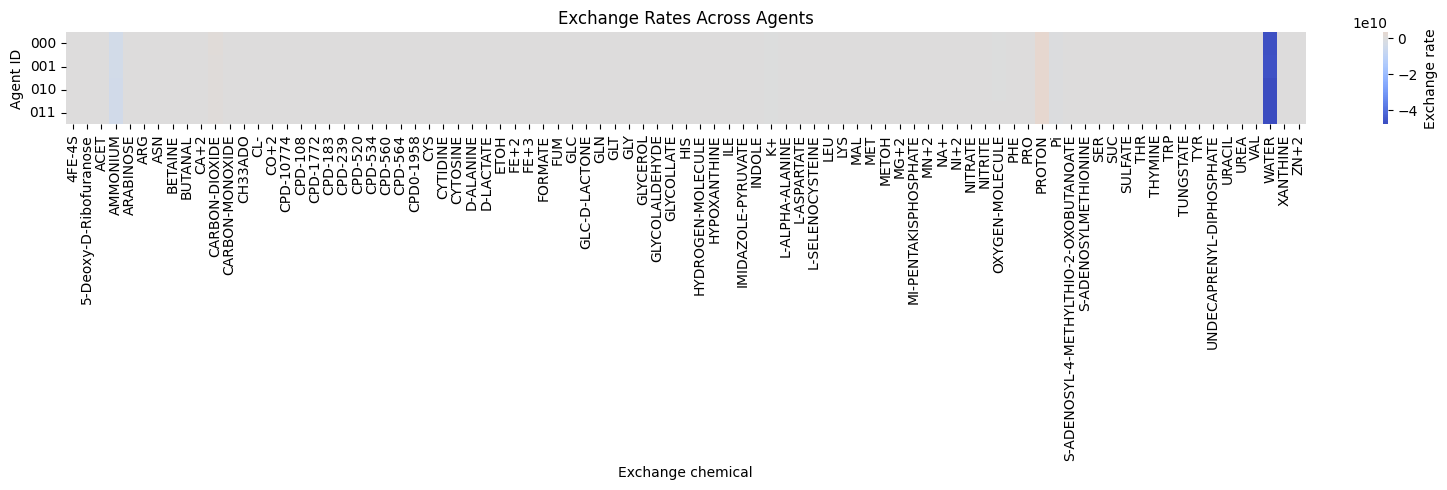

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Build DataFrame: rows=agents, columns=exchange chemicals, values=exchange rates
exchange_data = []
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    row = {'agent_id': agent_id}
    for chem, rate in exchange.items():
        row[chem] = rate
    exchange_data.append(row)

exchange_df = pd.DataFrame(exchange_data)
exchange_df = exchange_df.set_index('agent_id').fillna(0)

# Plot heatmap
plt.figure(figsize=(min(20, 0.5*len(exchange_df.columns)), min(12, 0.3*len(exchange_df))))
sns.heatmap(exchange_df, cmap='coolwarm', center=0, annot=False, cbar_kws={'label': 'Exchange rate'})
plt.xlabel('Exchange chemical')
plt.ylabel('Agent ID')
plt.title('Exchange Rates Across Agents')
plt.tight_layout()
plt.show()

/tmp/ipykernel_908641/3420995705.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


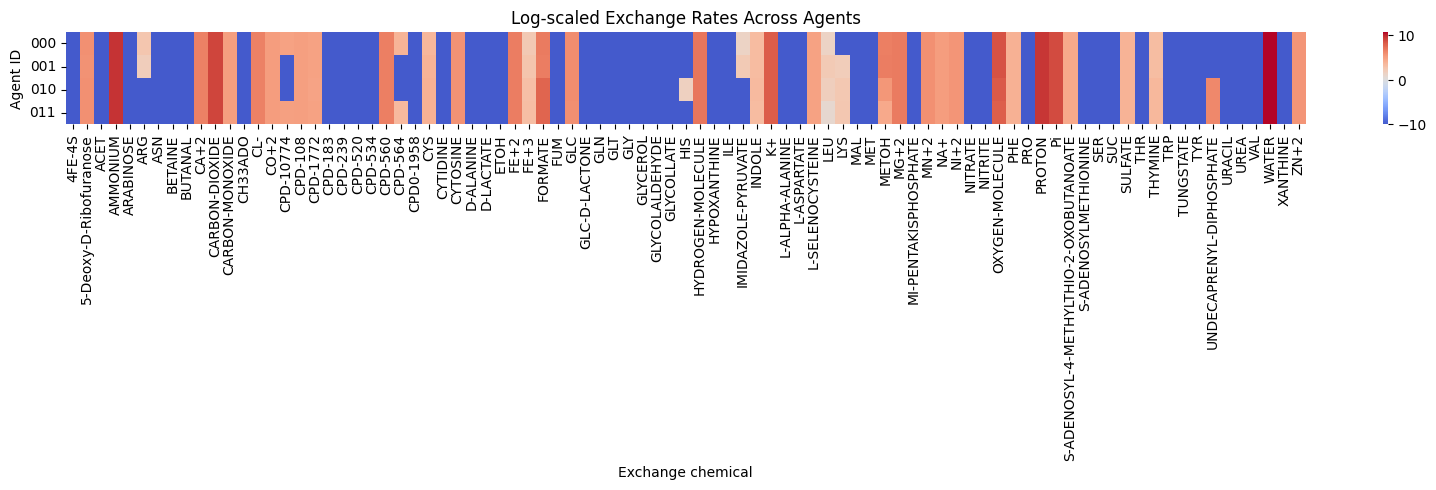

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Build DataFrame: rows=agents, columns=exchange chemicals, values=exchange rates
exchange_data = []
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    row = {'agent_id': agent_id}
    for chem, rate in exchange.items():
        row[chem] = rate
    exchange_data.append(row)

exchange_df = pd.DataFrame(exchange_data)
exchange_df = exchange_df.set_index('agent_id').fillna(0)

# Log transform: absolute values only, add small constant to avoid log(0)
e1 = 1e-10
log_exchange_df = np.log10(np.abs(exchange_df) + e1)

# Plot heatmap
plt.figure(figsize=(min(20, 0.5*len(log_exchange_df.columns)), min(12, 0.3*len(log_exchange_df))))
sns.heatmap(log_exchange_df, cmap='coolwarm', center=0, annot=False)
plt.xlabel('Exchange chemical')
plt.ylabel('Agent ID')
plt.title('Log-scaled Exchange Rates Across Agents')
plt.tight_layout()
plt.show()

/tmp/ipykernel_908641/3316751008.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


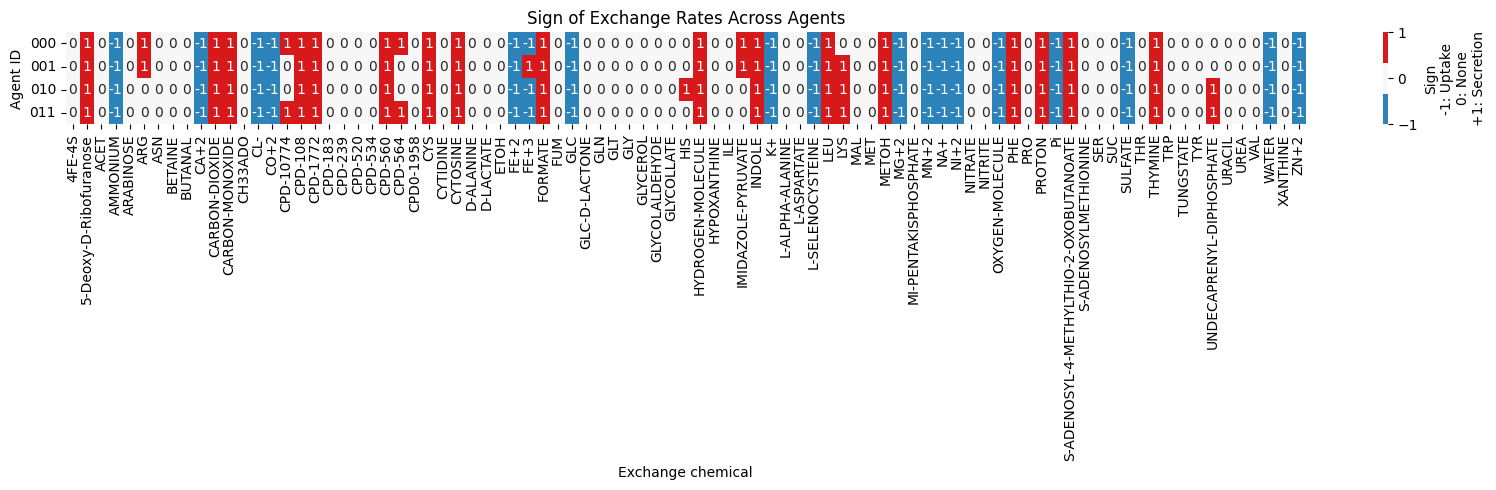

In [9]:
# Plot sign of exchange readings for each agent and chemical
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assumes exchange_df is defined: rows=agent_id, columns=chemicals
# If not, recreate exchange_df from your data as in previous cells

# Compute sign matrix: -1 (uptake), 0 (none), +1 (secretion)
sign_df = np.sign(exchange_df)

plt.figure(figsize=(min(20, 0.5*len(sign_df.columns)), min(12, 0.3*len(sign_df))))
sns.heatmap(sign_df, cmap=sns.color_palette(["#2b83ba", "#f7f7f7", "#d7191c"], as_cmap=True), center=0, annot=True, fmt="d",
            cbar_kws={'label': 'Sign\n-1: Uptake\n0: None\n+1: Secretion'})
plt.xlabel('Exchange chemical')
plt.ylabel('Agent ID')
plt.title('Sign of Exchange Rates Across Agents')
plt.tight_layout()
plt.show()

In [10]:
# Show first 5 zero exchange readings (agent, chemical, value)
import pandas as pd

# Find zero entries in exchange_df
zero_entries = []
for agent in exchange_df.index:
    for chem in exchange_df.columns:
        if exchange_df.loc[agent, chem] == 0:
            zero_entries.append((agent, chem, 0))
            if len(zero_entries) == 5:
                break
    if len(zero_entries) == 5:
        break

# Display
print("First 5 zero exchange readings:")
for entry in zero_entries:
    print(f"Agent: {entry[0]}, Chemical: {entry[1]}, Value: {entry[2]}")

First 5 zero exchange readings:
Agent: 000, Chemical: 4FE-4S, Value: 0
Agent: 000, Chemical: ACET, Value: 0
Agent: 000, Chemical: ARABINOSE, Value: 0
Agent: 000, Chemical: ASN, Value: 0
Agent: 000, Chemical: BETAINE, Value: 0


/tmp/ipykernel_908641/1856500740.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


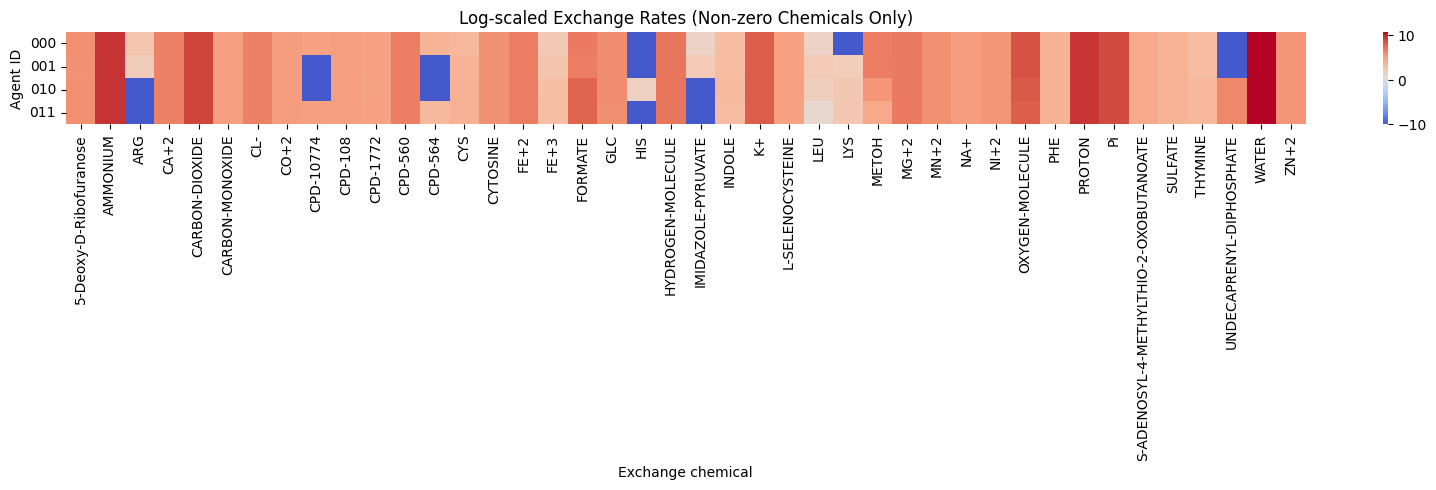

In [11]:
# Plot log-scaled heatmap for chemicals with at least one non-zero value
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Filter columns (chemicals) with at least one non-zero value
nonzero_chems = exchange_df.columns[(exchange_df != 0).any(axis=0)]
filtered_df = exchange_df[nonzero_chems]

# Log transform: absolute values only, add small constant to avoid log(0)
e1 = 1e-10
log_filtered_df = np.log10(np.abs(filtered_df) + e1)

plt.figure(figsize=(min(20, 0.5*len(log_filtered_df.columns)), min(12, 0.3*len(log_filtered_df))))
sns.heatmap(log_filtered_df, cmap='coolwarm', center=0, annot=False)
plt.xlabel('Exchange chemical')
plt.ylabel('Agent ID')
plt.title('Log-scaled Exchange Rates (Non-zero Chemicals Only)')
plt.tight_layout()
plt.show()

### Extract exchange rates

In [17]:
from pathlib import Path
import re

import pandas as pd

project_name = "baseline_2gen_seed_0_colony_t6000"

def normalize_exchange_name(name):
    return re.sub(r"\[.*?\]", "", str(name)).strip()

# Build wide matrix first: rows=agents, columns=chemicals, values=exchange rates
exchange_data = []
for agent_id in agent_ids:
    env = agents[agent_id].get("environment", {})
    exchange = env.get("exchange", {})

    row = {"agent_id": agent_id}
    for chem, rate in exchange.items():
        row[normalize_exchange_name(chem)] = rate
    exchange_data.append(row)

exchange_df = pd.DataFrame(exchange_data).set_index("agent_id").fillna(0)

# Summarize by chemical: rows=chemicals
ranked_exchange_df = pd.DataFrame(
    {
        "chemical": exchange_df.columns,
        "mean_exchange_rate": exchange_df.mean(axis=0).values,
        "mean_abs_exchange_rate": exchange_df.abs().mean(axis=0).values,
        "max_exchange_rate": exchange_df.max(axis=0).values,
        "min_exchange_rate": exchange_df.min(axis=0).values,
        "max_abs_exchange_rate": exchange_df.abs().max(axis=0).values,
    }
).sort_values(
    by="max_abs_exchange_rate",
    ascending=False,
    ignore_index=True,
)

display(ranked_exchange_df)
print("Shape:", ranked_exchange_df.shape)

out_path = Path(
    "/user/home/il22158/work/vEcoli/reading/results/colony/"
    f"ranked_external_exchange__{project_name}.csv"
)
out_path.parent.mkdir(parents=True, exist_ok=True)
ranked_exchange_df.to_csv(out_path, index=False)

print(f"Saved ranked exchange summary: {out_path}")

,chemical,mean_exchange_rate,mean_abs_exchange_rate,max_exchange_rate,min_exchange_rate,max_abs_exchange_rate
0,WATER,-4.732753e+10,4.732753e+10,-46653325381,-47946468814,47946468814
1,AMMONIUM,-4.115869e+09,4.115869e+09,-4075870702,-4149945034,4149945034
2,PROTON,3.471591e+09,3.471591e+09,3493226680,3445322140,3493226680
3,CARBON-DIOXIDE,1.048475e+09,1.048475e+09,1091144721,997691067,1091144721
4,Pi,-6.368939e+08,6.368939e+08,-630611371,-642199447,642199447
...,...,...,...,...,...,...
82,TYR,0.000000e+00,0.000000e+00,0,0,0
83,UREA,0.000000e+00,0.000000e+00,0,0,0
84,URACIL,0.000000e+00,0.000000e+00,0,0,0
85,VAL,0.000000e+00,0.000000e+00,0,0,0


Shape: (87, 6)
Saved ranked exchange summary: /user/home/il22158/work/vEcoli/reading/results/colony/ranked_external_exchange__baseline_2gen_seed_0_colony_t6000.csv


In [12]:
import json
import math
import re

UNIT_RE = re.compile(r"^!units\[(.+?)\s+([^\]]+)\]$", re.IGNORECASE)

def parse_units_token(raw):
    """
    raw: e.g. '!units[0.987 millimolar]' or '!units[inf millimolar]'
    returns dict with value, unit, is_inf, is_units_token
    """
    if not isinstance(raw, str):
        return {"value": raw, "unit": None, "is_inf": False, "is_units_token": False}

    m = UNIT_RE.match(raw.strip())
    if not m:
        return {"value": raw, "unit": None, "is_inf": False, "is_units_token": False}

    val_str, unit = m.group(1).strip(), m.group(2).strip()
    is_inf = val_str.lower() in {"inf", "+inf", "infinity", "+infinity", "∞"}

    if is_inf:
        value = math.inf
    else:
        value = float(val_str)

    return {"value": value, "unit": unit, "is_inf": is_inf, "is_units_token": True}


# Example: read from colony JSON and mark infinite-availability entities
with open("/user/home/il22158/work/vEcoli/data/baseline_2gen_seed_0_colony_t6000.json", "r") as f:
    data = json.load(f)

agents = data["agents"]
inf_entities = set()

for agent_id, agent in agents.items():
    ext = agent.get("boundary", {}).get("external", {})
    for mol, raw in ext.items():
        parsed = parse_units_token(raw)
        if parsed["is_inf"] and parsed["unit"].lower() == "millimolar":
            inf_entities.add(mol)

print("Inf-available molecules:", sorted(inf_entities))

# Later comparison: exclude these
# filtered_df = df[~df["chemical"].isin(inf_entities)]

Inf-available molecules: ['CARBON-DIOXIDE', 'CO+2', 'FE+2', 'L-SELENOCYSTEINE', 'MN+2', 'NI+2', 'OXYGEN-MOLECULE', 'WATER', 'ZN+2']


In [13]:
out_dir = Path("/user/home/il22158/work/vEcoli/reading/results/colony")
file_name = f"inf_available_chemicals__{project_name}.csv"
out_path = out_dir / file_name
pd.DataFrame({"chemical": sorted(inf_entities)}).to_csv(out_path, index=False)
print(f"Saved inf-available chemicals: {out_path}")

Saved inf-available chemicals: /user/home/il22158/work/vEcoli/reading/results/colony/inf_available_chemicals__baseline_2gen_seed_0_colony_t6000.csv


In [15]:
import json

json_path = "/user/home/il22158/work/vEcoli/data/baseline_2gen_seed_0_colony_t6000.json"

with open(json_path, "r") as f:
    data = json.load(f)

agents = data["agents"]

# Print mmol_to_counts for each agent (raw value from JSON)
for agent_id in sorted(agents):
    mmol_to_counts = agents[agent_id].get("boundary", {}).get("mmol_to_counts")
    print(agent_id, mmol_to_counts)

000 !units[771553.3883459674 / millimolar]
001 !units[762474.9073928331 / millimolar]
010 !units[772383.1576104428 / millimolar]
011 !units[776935.0041671057 / millimolar]


Clarification:

In the code, mmol_to_counts is defined as Avogadro × volume, then converted to L/mmol, not as a concentration value itself: derive_globals.py:82, derive_globals.py:121, derive_globals.py:139-144.

In the exchange process, they explicitly say concentrations are mmol/L, then multiply by mmol_to_counts to get counts: exchange.py:57-64.

In [16]:
from pathlib import Path
import re
import pandas as pd

project_name = "baseline_2gen_seed_0_colony_t6000"


def normalize_exchange_name(name):
    return re.sub(r"\[.*?\]", "", str(name)).strip()


def parse_units_number(value):
    # Works for strings like "!units[771553.3883459674 / millimolar]"
    if isinstance(value, str):
        m = re.search(r"\[([+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)", value)
        if m:
            return float(m.group(1))
    return float(value)


def counts_to_mM(delta_counts, mmol_to_counts_raw):
    mmol_to_counts = parse_units_number(mmol_to_counts_raw)  # counts per mM
    if mmol_to_counts <= 0:
        return pd.NA
    return delta_counts / mmol_to_counts  # mM per step


# Build wide matrix first: rows=agents, columns=chemicals, values=exchange (mM per step)
exchange_data = []
for agent_id in agent_ids:
    agent = agents[agent_id]
    env = agent.get("environment", {})
    boundary = agent.get("boundary", {})
    exchange = env.get("exchange", {})

    mmol_to_counts_raw = boundary.get("mmol_to_counts")

    row = {"agent_id": agent_id}
    for chem, rate in exchange.items():
        row[normalize_exchange_name(chem)] = counts_to_mM(rate, mmol_to_counts_raw)
    exchange_data.append(row)

exchange_df = pd.DataFrame(exchange_data).set_index("agent_id").fillna(0)

# Summarize by chemical: rows=chemicals
ranked_exchange_df = pd.DataFrame(
    {
        "chemical": exchange_df.columns,
        "mean_exchange": exchange_df.mean(axis=0).values,
        "mean_abs_exchange": exchange_df.abs().mean(axis=0).values,
        "max_exchange": exchange_df.max(axis=0).values,
        "min_exchange": exchange_df.min(axis=0).values,
        "max_abs_exchange": exchange_df.abs().max(axis=0).values,
        "unit": "mM",
    }
).sort_values(
    by="max_abs_exchange",
    ascending=False,
    ignore_index=True,
)

display(ranked_exchange_df)
print("Shape:", ranked_exchange_df.shape)

out_path = Path(
    "/user/home/il22158/work/vEcoli/reading/results/colony/"
    f"ranked_external_exchange__{project_name}__mM.csv"
)
out_path.parent.mkdir(parents=True, exist_ok=True)
ranked_exchange_df.to_csv(out_path, index=False)

print(f"Saved ranked exchange summary: {out_path}")

,chemical,mean_exchange,mean_abs_exchange,max_exchange,min_exchange,max_abs_exchange,unit
0,WATER,-61396.338986,61396.338986,-60893.162160,-61793.161915,61793.161915,mM
1,AMMONIUM,-5339.490276,5339.490276,-5303.856184,-5367.093398,5367.093398,mM
2,PROTON,4503.720369,4503.720369,4518.603965,4484.076374,4518.603965,mM
3,CARBON-DIOXIDE,1360.462602,1360.462602,1414.218040,1284.137105,1414.218040,mM
4,Pi,-826.237690,826.237690,-819.899961,-831.451904,831.451904,mM
...,...,...,...,...,...,...,...
82,TYR,0.000000,0.000000,0.000000,0.000000,0.000000,mM
83,UREA,0.000000,0.000000,0.000000,0.000000,0.000000,mM
84,URACIL,0.000000,0.000000,0.000000,0.000000,0.000000,mM
85,VAL,0.000000,0.000000,0.000000,0.000000,0.000000,mM


Shape: (87, 7)
Saved ranked exchange summary: /user/home/il22158/work/vEcoli/reading/results/colony/ranked_external_exchange__baseline_2gen_seed_0_colony_t6000__mM.csv


gDCW means grams of Dry Cell Weight: the cell mass excluding water.

So mmol/gDCW/h means “millimoles exchanged per gram of dry biomass per hour,” which normalizes flux by cell size.

### Bar plot

<Figure size 2800x700 with 0 Axes>

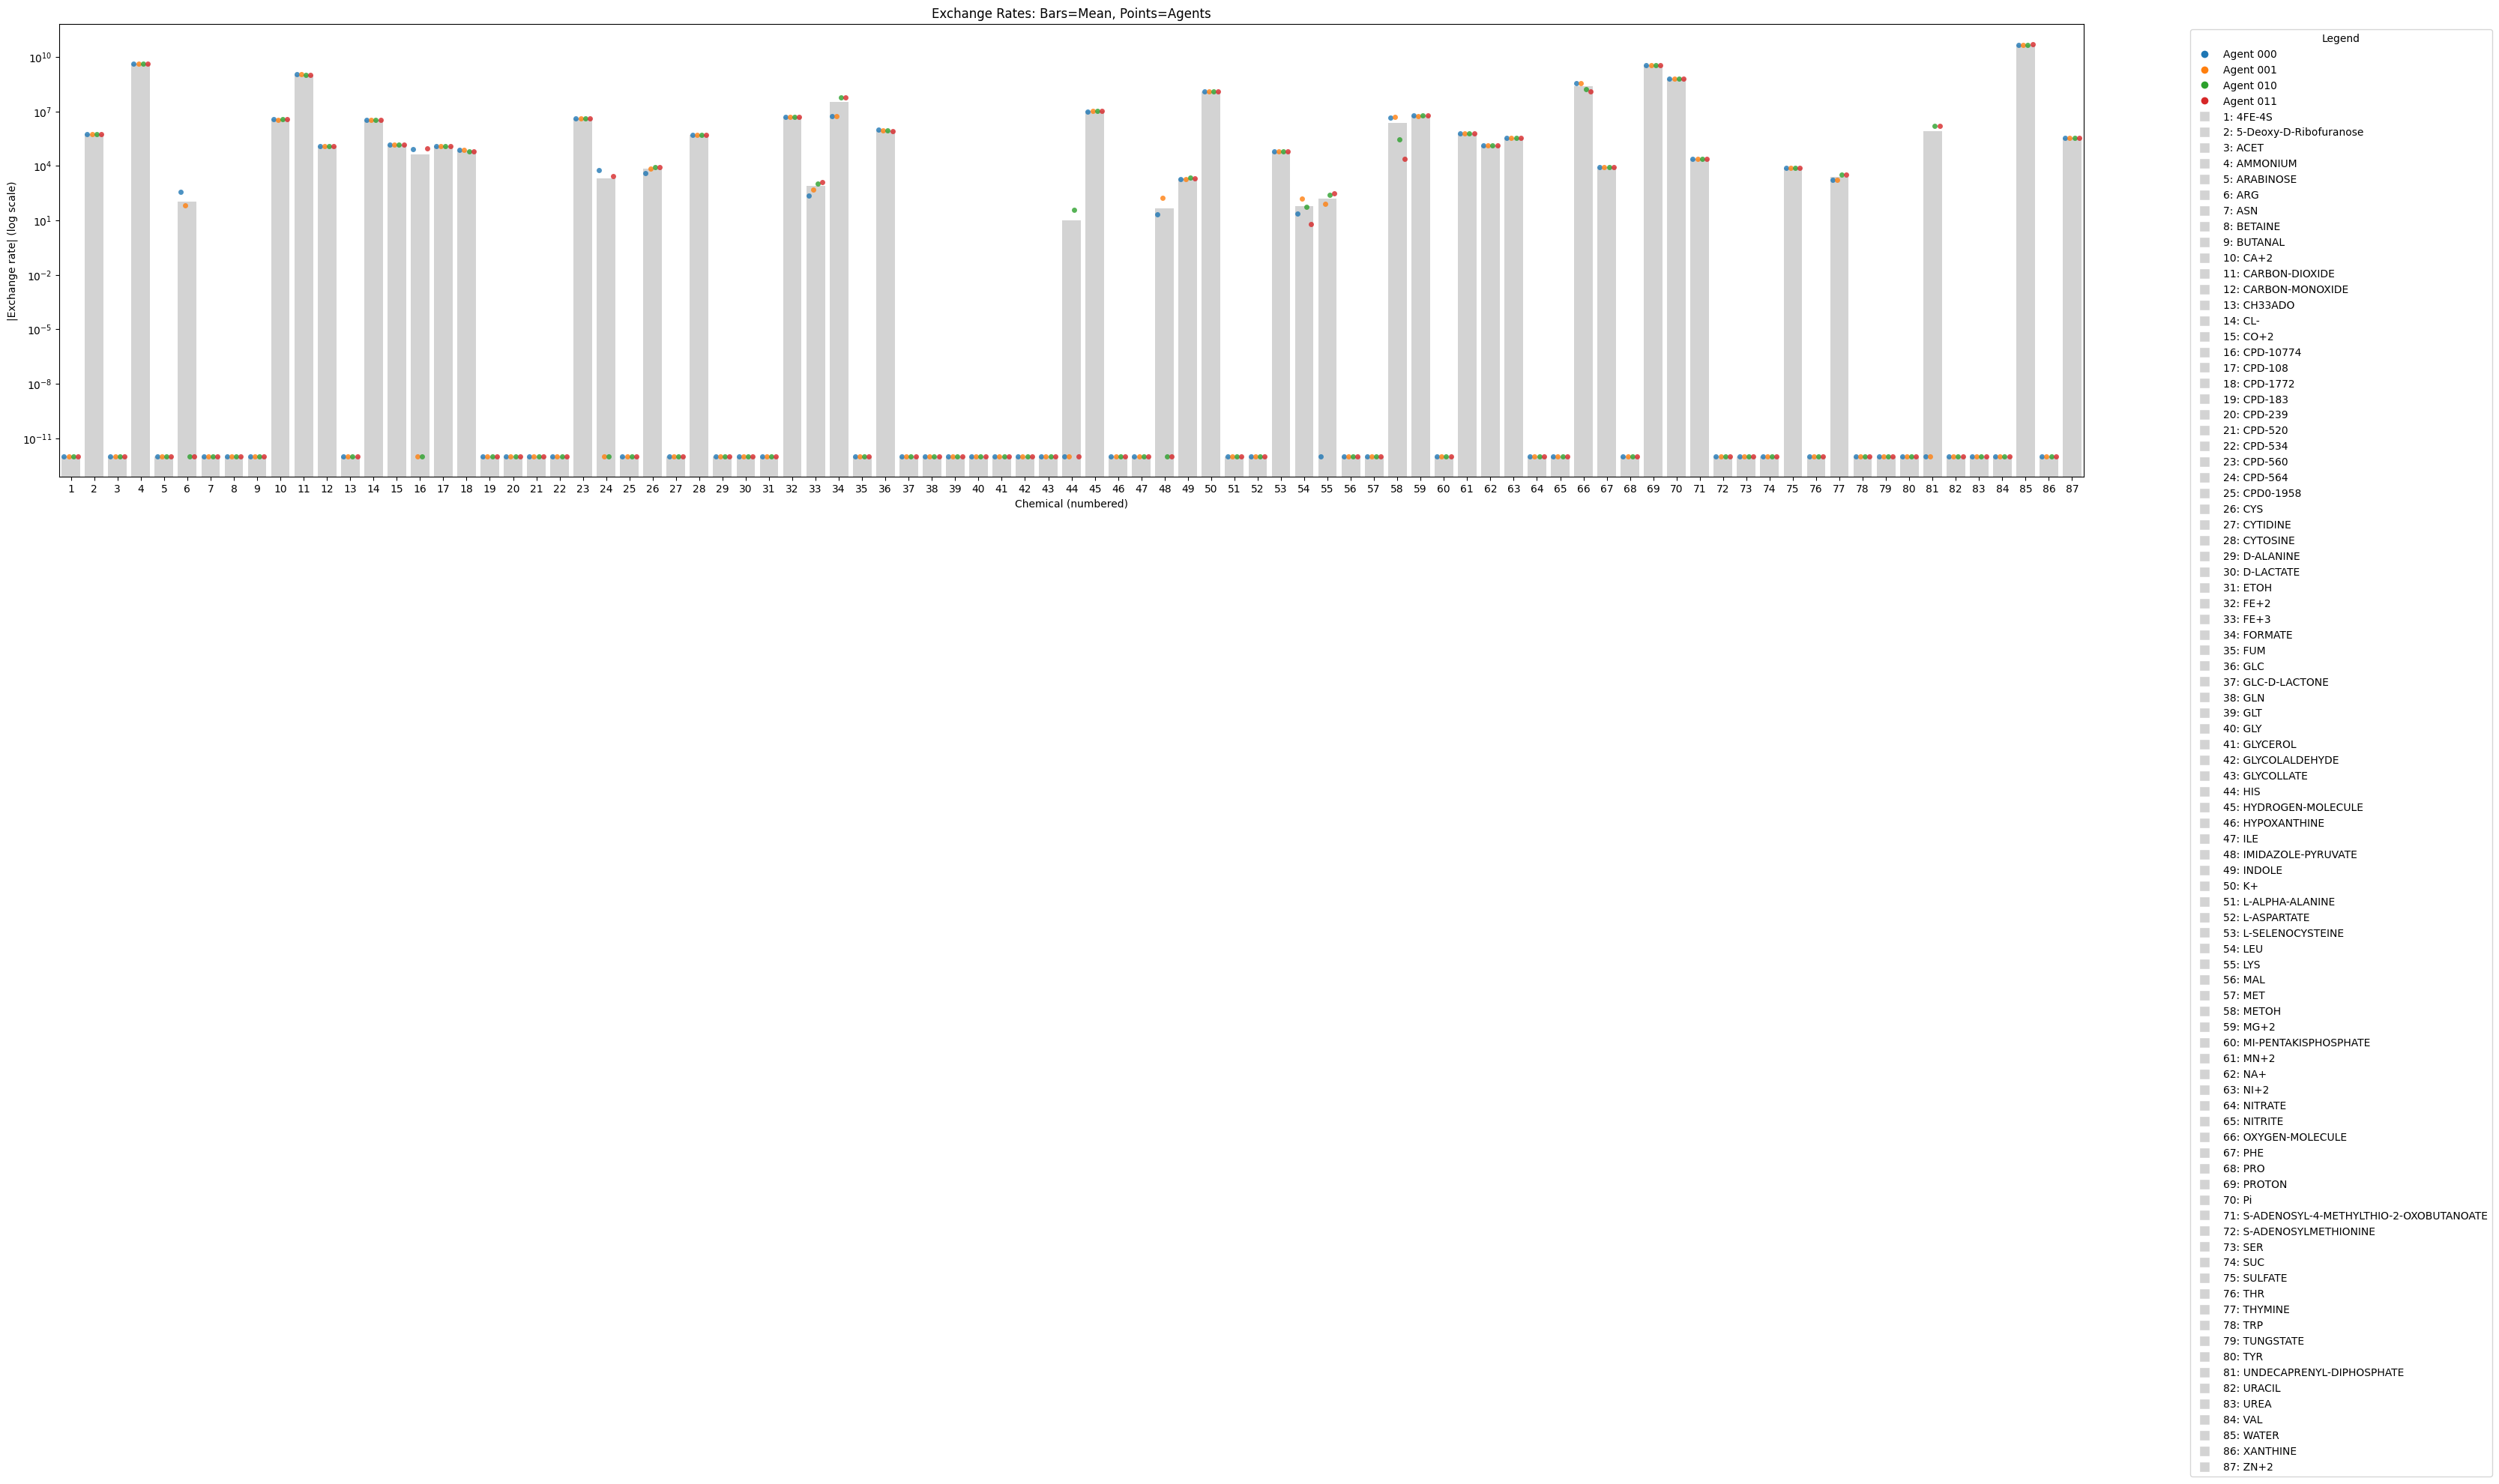

In [17]:
# Plot: Each chemical as a bar group, each agent as a point (dot strip) on log scale
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Recreate df_melt for this cell
# Assumes exchange_df is defined: rows=agent_id, columns=chemicals
# If not, you can create exchange_df from your data as in previous cells

df_melt = exchange_df.reset_index().melt(id_vars='agent_id', var_name='chemical', value_name='rate')

# Widen the figure for better x-axis spacing
fig_width = max(12, min(2 + len(exchange_df.columns) * 2.2, 28))
plt.figure(figsize=(fig_width, 7))
df_melt['abs_rate'] = np.abs(df_melt['rate']) + 1e-12
mean_rates = df_melt.groupby('chemical')['abs_rate'].mean().reset_index()

# Assign numbers to chemicals
chemical_labels = list(mean_rates['chemical'])
chemical_numbers = {chem: i+1 for i, chem in enumerate(chemical_labels)}
df_melt['chem_num'] = df_melt['chemical'].map(chemical_numbers)
mean_rates['chem_num'] = mean_rates['chemical'].map(chemical_numbers)

# Plot using chemical numbers as x
plt.figure(figsize=(fig_width, 7))
sns.barplot(data=mean_rates, x='chem_num', y='abs_rate', color='lightgray', zorder=1)
# Use hue for agent_id to color dots by agent
sns.stripplot(data=df_melt, x='chem_num', y='abs_rate', hue='agent_id',
              dodge=True, jitter=True, marker='o', alpha=0.8, zorder=2, legend=False)

plt.yscale('log')
plt.xlabel('Chemical (numbered)')
plt.ylabel('|Exchange rate| (log scale)')
plt.title('Exchange Rates: Bars=Mean, Points=Agents')
plt.tight_layout()

# Set x-ticks to numbers and show mapping in legend
plt.xticks(ticks=range(len(chemical_labels)), labels=[f"{i+1}" for i in range(len(chemical_labels))])

# Build legend: mapping number to chemical and agent colors
# Get agent colors from seaborn palette
unique_agents = sorted(df_melt['agent_id'].unique())
palette = sns.color_palette(n_colors=len(unique_agents))
agent_color_map = dict(zip(unique_agents, palette))

legend_elements = [
    *[Line2D([0], [0], marker='o', color='w', label=f"Agent {agent}", markerfacecolor=agent_color_map[agent], markersize=8)
      for agent in unique_agents],
    *[Line2D([0], [0], marker='s', color='w', label=f"{i+1}: {chem}", markerfacecolor='lightgray', markersize=10)
      for i, chem in enumerate(chemical_labels)]
]
plt.legend(handles=legend_elements, title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

- Definition:
"Exchange reading" refers to the process of tracking the movement of molecules between the cell and its environment, typically implemented as "exchange reactions" in metabolic models. In the codebase, this is handled by the Exchange process, which updates molecule counts based on uptake and secretion rates.

- Directionality:
The convention in the code (see modular_fba.py) is that exchange fluxes are defined as pointing out of the system (cell), even though exchanges can represent both import (uptake) and export (secretion).
The sign of the exchange value is not always positive:
Uptake (import) is typically represented as a negative flux (into the cell).
Secretion (export) is positive (out of the cell).

- Summary:

1. Exchange readings can be positive or negative, depending on whether the molecule is being taken up or secreted.
2. The codebase uses negative values for uptake and positive for secretion, following standard metabolic modeling conventions.

- References:

1. exchange.py: Implements molecule movement with uptake and secretion rates.
2. modular_fba.py: Exchange reactions are set as pointing out of the system, but can represent both directions.

## Read from 2-generation Trial Run

In [ ]:
import json
with open('/user/home/il22158/work/vEcoli/data/baseline_2gen_seed_0_colony_t6000.json', 'r') as f:
    data = json.load(f)

# Check boundary (positions), listeners (growth rate), timeline
agent = data['agents']['000']
print('=== boundary (spatial info) ===')
print(agent.get('boundary', 'N/A'))
print()
print('=== listeners keys ===')
if 'listeners' in agent:
    print(list(agent['listeners'].keys())[:20])
print()
print('=== global_time ===')
print(agent.get('global_time', 'N/A'))
print()
print('=== timeline sample ===')
tl = agent.get('timeline', [])
print('Timeline length:', len(tl) if tl else 0)
print('First item:', tl[0][:100] if tl else 'empty')

=== boundary (spatial info) ===
{'external': {'ARG': '!units[0.0 millimolar]', 'ASN': '!units[0.0 millimolar]', 'CYS': '!units[0.0 millimolar]', 'GLN': '!units[0.0 millimolar]', 'GLT': '!units[0.0 millimolar]', 'GLY': '!units[0.0 millimolar]', 'HIS': '!units[0.0 millimolar]', 'ILE': '!units[0.0 millimolar]', 'L-ALPHA-ALANINE': '!units[0.0 millimolar]', 'L-ASPARTATE': '!units[0.0 millimolar]', 'L-SELENOCYSTEINE': '!units[inf millimolar]', 'LEU': '!units[0.0 millimolar]', 'LYS': '!units[0.0 millimolar]', 'MET': '!units[0.0 millimolar]', 'PHE': '!units[0.0 millimolar]', 'PRO': '!units[0.0 millimolar]', 'SER': '!units[0.0 millimolar]', 'THR': '!units[0.0 millimolar]', 'TRP': '!units[0.0 millimolar]', 'TYR': '!units[0.0 millimolar]', 'VAL': '!units[0.0 millimolar]', 'GLC': '!units[0.9870576641167453 millimolar]', 'ACET': '!units[0.0 millimolar]', 'FUM': '!units[0.0 millimolar]', 'MAL': '!units[0.0 millimolar]', 'SUC': '!units[0.0 millimolar]', 'OXYGEN-MOLECULE': '!units[inf millimolar]', 'A

KeyError: 0

In [ ]:
import json
with open('/user/home/il22158/work/vEcoli/data/baseline_2gen_seed_0_colony_t6000.json', 'r') as f:
    data = json.load(f)

agent = data['agents']['000']
# Check mass listener for growth rate
print('=== mass listener ===')
mass = agent['listeners'].get('mass', {})
print(list(mass.keys()) if isinstance(mass, dict) else mass[:5])
print()
# Check growth_limits
print('=== growth_limits listener ===')
gl = agent['listeners'].get('growth_limits', {})
print(list(gl.keys()) if isinstance(gl, dict) else gl[:5])
print()
# Check dimensions
print('=== dimensions (spatial field) ===')
print(data['dimensions'])

=== mass listener ===
['cell_mass', 'water_mass', 'dry_mass', 'rna_mass', 'rRna_mass', 'tRna_mass', 'mRna_mass', 'dna_mass', 'protein_mass', 'smallMolecule_mass', 'volume', 'protein_mass_fraction', 'rna_mass_fraction', 'growth', 'instantaneous_growth_rate', 'dry_mass_fold_change', 'protein_mass_fold_change', 'rna_mass_fold_change', 'small_molecule_fold_change', 'projection_mass', 'cytosol_mass', 'extracellular_mass', 'flagellum_mass', 'membrane_mass', 'outer_membrane_mass', 'periplasm_mass', 'pilus_mass', 'inner_membrane_mass', 'expected_mass_fold_change']

=== growth_limits listener ===
['fraction_trna_charged', 'aa_allocated', 'aa_pool_size', 'aa_request_size', 'active_ribosome_allocated', 'net_charged', 'aas_used', 'aa_count_diff', 'original_aa_supply', 'aa_in_media', 'synthetase_conc', 'uncharged_trna_conc', 'charged_trna_conc', 'aa_conc', 'ribosome_conc', 'fraction_aa_to_elongate', 'aa_supply', 'aa_synthesis', 'aa_import', 'aa_export', 'aa_importers', 'aa_exporters', 'aa_supply_en

: 

: 

Colony snapshot at t=6000.0s | 4 cells: ['000', '001', '010', '011']
cell_id  growth_rate   length        mass  ppgpp_conc
    000     0.000268 1.964601 1409.313998   52.228365
    001     0.000257 1.945407 1392.731309   59.362662
    010     0.000260 1.966355 1410.829649   60.086722
    011     0.000231 1.975979 1419.144020   69.293385


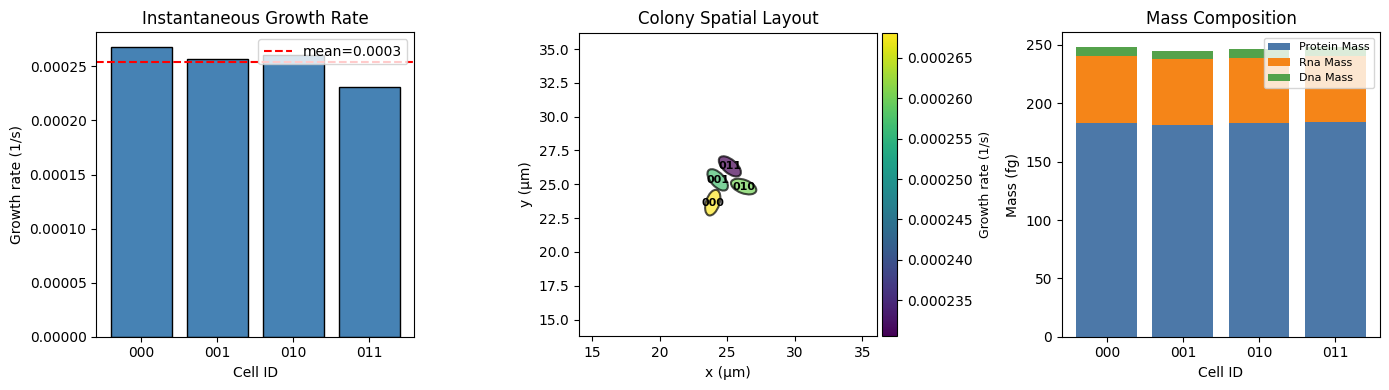


--- Colony Summary ---
Growth rate: 0.00025 ± 0.00002 /s
Cell length: 1.96 ± 0.01 μm
ppGpp conc:  60.243 ± 6.999


: 

: 

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import re

# Load colony snapshot
json_path = '/user/home/il22158/work/vEcoli/data/baseline_2gen_seed_0_colony_t6000.json'
with open(json_path, 'r') as f:
    colony_data = json.load(f)

def parse_unit(val):
    """Extract numeric value from unit string like '!units[1.23 micrometer]'"""
    if isinstance(val, str) and val.startswith('!units['):
        match = re.search(r'\[([-\d.eE+]+)', val)
        return float(match.group(1)) if match else np.nan
    return val

# Extract data for all cells
agents = colony_data['agents']
cell_ids = sorted(agents.keys())
print(f"Colony snapshot at t={agents[cell_ids[0]]['global_time']}s | {len(cell_ids)} cells: {cell_ids}")

# Build summary dataframe
cell_data = []
for cid in cell_ids:
    a = agents[cid]
    b = a['boundary']
    m = a['listeners']['mass']
    gl = a['listeners']['growth_limits']
    
    cell_data.append({
        'cell_id': cid,
        'x': parse_unit(b['location'][0]),
        'y': parse_unit(b['location'][1]),
        'angle': b['angle'],
        'length': parse_unit(b['length']),
        'width': parse_unit(b['width']),
        'volume': parse_unit(b['volume']),
        'mass': parse_unit(b['mass']),
        'growth_rate': m['instantaneous_growth_rate'],
        'dry_mass': m['dry_mass'],
        'protein_mass': m['protein_mass'],
        'rna_mass': m['rna_mass'],
        'dna_mass': m['dna_mass'],
        'frac_trna_charged': np.mean(gl['fraction_trna_charged']),
        'ppgpp_conc': gl['ppgpp_conc'],
    })

import pandas as pd
df = pd.DataFrame(cell_data)
print(df[['cell_id', 'growth_rate', 'length', 'mass', 'ppgpp_conc']].to_string(index=False))

# --- Plot 1: Growth rate comparison ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.bar(df['cell_id'], df['growth_rate'], color='steelblue', edgecolor='k')
ax.set_xlabel('Cell ID')
ax.set_ylabel('Growth rate (1/s)')
ax.set_title('Instantaneous Growth Rate')
ax.axhline(df['growth_rate'].mean(), color='red', linestyle='--', label=f"mean={df['growth_rate'].mean():.4f}")
ax.legend()

# --- Plot 2: Spatial colony layout with colorbar ---
ax = axes[1]
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Normalize growth rate for colormap
norm = mcolors.Normalize(vmin=df['growth_rate'].min(), vmax=df['growth_rate'].max())
cmap = plt.cm.viridis

for _, row in df.iterrows():
    from matplotlib.patches import Ellipse
    ellipse = Ellipse((row['x'], row['y']), width=row['length'], height=row['width'],
                      angle=np.degrees(row['angle']), alpha=0.7, edgecolor='k', linewidth=1.5,
                      facecolor=cmap(norm(row['growth_rate'])))
    ax.add_patch(ellipse)
    ax.text(row['x'], row['y'], row['cell_id'], ha='center', va='center', fontsize=8, color='black', fontweight='bold')

# Auto-scale to cell positions with padding
pad = df['length'].max() * 5
ax.set_xlim(df['x'].min() - pad, df['x'].max() + pad)
ax.set_ylim(df['y'].min() - pad, df['y'].max() + pad)
ax.set_aspect('equal')
ax.set_xlabel('x (μm)')
ax.set_ylabel('y (μm)')
ax.set_title('Colony Spatial Layout')

# Add colorbar for growth rate
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('Growth rate (1/s)', fontsize=9)

# --- Plot 3: Mass composition ---
ax = axes[2]
mass_components = ['protein_mass', 'rna_mass', 'dna_mass']
x = np.arange(len(cell_ids))
bottom = np.zeros(len(cell_ids))
colors = ['#4c78a8', '#f58518', '#54a24b']
for comp, c in zip(mass_components, colors):
    ax.bar(x, df[comp], bottom=bottom, label=comp.replace('_', ' ').title(), color=c)
    bottom += df[comp].values
ax.set_xticks(x)
ax.set_xticklabels(cell_ids)
ax.set_xlabel('Cell ID')
ax.set_ylabel('Mass (fg)')
ax.set_title('Mass Composition')
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# --- Additional: Key colony metrics ---
print(f"\n--- Colony Summary ---")
print(f"Growth rate: {df['growth_rate'].mean():.5f} ± {df['growth_rate'].std():.5f} /s")
print(f"Cell length: {df['length'].mean():.2f} ± {df['length'].std():.2f} μm")
print(f"ppGpp conc:  {df['ppgpp_conc'].mean():.3f} ± {df['ppgpp_conc'].std():.3f}")

**Spatial Graph Construction:**
Each cell is drawn as an **ellipse** using `matplotlib.patches.Ellipse` with:
- **Position**: `(x, y)` from `boundary['location']` (cell centroid in μm)
- **Size**: `width=length`, `height=width` (cell dimensions in μm)
- **Orientation**: `angle` from `boundary['angle']` (converted to degrees)
- **Color**: mapped to growth rate via `viridis` colormap (brighter = faster growth)

The plot auto-scales to the cell bounding box + 5× max cell length as padding.

## Read from 3rd gen

Colony snapshot at t=9000.0s | 8 cells: ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111']
cell_id  growth_rate   length        mass  ppgpp_conc
   0000     0.000235 2.019226 1456.506990   66.944305
   0001     0.000227 1.993862 1434.593506   66.348744
   0010     0.000245 1.959072 1404.536990   55.807642
   0011     0.000227 1.980989 1423.471946   63.345405
   0100     0.000221 2.091283 1518.759169   75.019626
   0101     0.000237 2.101613 1527.683674   67.311172
   0110     0.000211 2.075279 1504.933365   72.999960
   0111     0.000581 2.032847 1468.274762   65.427193


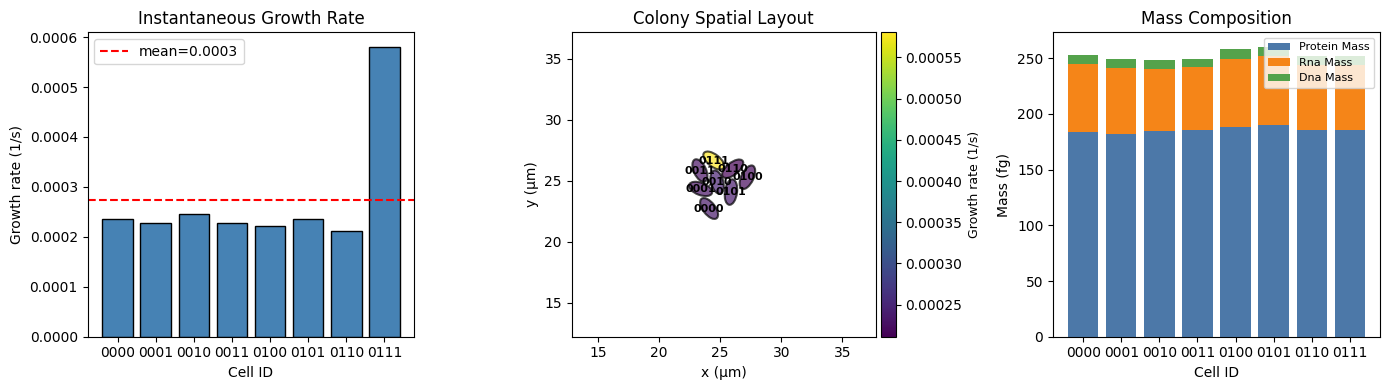


--- Colony Summary ---
Growth rate: 0.00027 ± 0.00012 /s
Cell length: 2.03 ± 0.05 μm
ppGpp conc:  66.651 ± 5.867


In [14]:
import json
import numpy as np
import matplotlib.pyplot as plt
import re

# Load colony snapshot
json_path = '/user/home/il22158/work/vEcoli/data/baseline_3rd_gen_seed_0_seed_0_colony_t3000.json'
with open(json_path, 'r') as f:
    colony_data = json.load(f)

def parse_unit(val):
    """Extract numeric value from unit string like '!units[1.23 micrometer]'"""
    if isinstance(val, str) and val.startswith('!units['):
        match = re.search(r'\[([-\d.eE+]+)', val)
        return float(match.group(1)) if match else np.nan
    return val

# Extract data for all cells
agents = colony_data['agents']
cell_ids = sorted(agents.keys())
print(f"Colony snapshot at t={agents[cell_ids[0]]['global_time']}s | {len(cell_ids)} cells: {cell_ids}")

# Build summary dataframe
cell_data = []
for cid in cell_ids:
    a = agents[cid]
    b = a['boundary']
    m = a['listeners']['mass']
    gl = a['listeners']['growth_limits']
    
    cell_data.append({
        'cell_id': cid,
        'x': parse_unit(b['location'][0]),
        'y': parse_unit(b['location'][1]),
        'angle': b['angle'],
        'length': parse_unit(b['length']),
        'width': parse_unit(b['width']),
        'volume': parse_unit(b['volume']),
        'mass': parse_unit(b['mass']),
        'growth_rate': m['instantaneous_growth_rate'],
        'dry_mass': m['dry_mass'],
        'protein_mass': m['protein_mass'],
        'rna_mass': m['rna_mass'],
        'dna_mass': m['dna_mass'],
        'frac_trna_charged': np.mean(gl['fraction_trna_charged']),
        'ppgpp_conc': gl['ppgpp_conc'],
    })

import pandas as pd
df = pd.DataFrame(cell_data)
print(df[['cell_id', 'growth_rate', 'length', 'mass', 'ppgpp_conc']].to_string(index=False))

# --- Plot 1: Growth rate comparison ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.bar(df['cell_id'], df['growth_rate'], color='steelblue', edgecolor='k')
ax.set_xlabel('Cell ID')
ax.set_ylabel('Growth rate (1/s)')
ax.set_title('Instantaneous Growth Rate')
ax.axhline(df['growth_rate'].mean(), color='red', linestyle='--', label=f"mean={df['growth_rate'].mean():.4f}")
ax.legend()

# --- Plot 2: Spatial colony layout with colorbar ---
ax = axes[1]
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Normalize growth rate for colormap
norm = mcolors.Normalize(vmin=df['growth_rate'].min(), vmax=df['growth_rate'].max())
cmap = plt.cm.viridis

for _, row in df.iterrows():
    from matplotlib.patches import Ellipse
    ellipse = Ellipse((row['x'], row['y']), width=row['length'], height=row['width'],
                      angle=np.degrees(row['angle']), alpha=0.7, edgecolor='k', linewidth=1.5,
                      facecolor=cmap(norm(row['growth_rate'])))
    ax.add_patch(ellipse)
    ax.text(row['x'], row['y'], row['cell_id'], ha='center', va='center', fontsize=8, color='black', fontweight='bold')

# Auto-scale to cell positions with padding
pad = df['length'].max() * 5
ax.set_xlim(df['x'].min() - pad, df['x'].max() + pad)
ax.set_ylim(df['y'].min() - pad, df['y'].max() + pad)
ax.set_aspect('equal')
ax.set_xlabel('x (μm)')
ax.set_ylabel('y (μm)')
ax.set_title('Colony Spatial Layout')

# Add colorbar for growth rate
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('Growth rate (1/s)', fontsize=9)

# --- Plot 3: Mass composition ---
ax = axes[2]
mass_components = ['protein_mass', 'rna_mass', 'dna_mass']
x = np.arange(len(cell_ids))
bottom = np.zeros(len(cell_ids))
colors = ['#4c78a8', '#f58518', '#54a24b']
for comp, c in zip(mass_components, colors):
    ax.bar(x, df[comp], bottom=bottom, label=comp.replace('_', ' ').title(), color=c)
    bottom += df[comp].values
ax.set_xticks(x)
ax.set_xticklabels(cell_ids)
ax.set_xlabel('Cell ID')
ax.set_ylabel('Mass (fg)')
ax.set_title('Mass Composition')
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# --- Additional: Key colony metrics ---
print(f"\n--- Colony Summary ---")
print(f"Growth rate: {df['growth_rate'].mean():.5f} ± {df['growth_rate'].std():.5f} /s")
print(f"Cell length: {df['length'].mean():.2f} ± {df['length'].std():.2f} μm")
print(f"ppGpp conc:  {df['ppgpp_conc'].mean():.3f} ± {df['ppgpp_conc'].std():.3f}")

**Spatial Graph Construction:**
Each cell is drawn as an **ellipse** using `matplotlib.patches.Ellipse` with:
- **Position**: `(x, y)` from `boundary['location']` (cell centroid in μm)
- **Size**: `width=length`, `height=width` (cell dimensions in μm)
- **Orientation**: `angle` from `boundary['angle']` (converted to degrees)
- **Color**: mapped to growth rate via `viridis` colormap (brighter = faster growth)

The plot auto-scales to the cell bounding box + 5× max cell length as padding.

## Env Factors - 3rd gen

### Load data

In [1]:
import json

with open('/user/home/il22158/work/vEcoli/data/baseline_3rd_gen_seed_0_seed_0_colony_t3000.json', 'r') as f:
    data = json.load(f)

agents = data['agents']
agent_ids = sorted(agents.keys())

# Get all unique keys (categories) across all agents
all_keys = set()
for agent in agents.values():
    all_keys.update(agent.keys())

print("Agent names (IDs):")
print(agent_ids)
print("\nUnique categories (keys):")
print(sorted(all_keys))

Agent names (IDs):
['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111']

Unique categories (keys):
['allocate', 'allocator_rng', 'boundary', 'bulk', 'bulk_dtypes', 'cytoplasm', 'divide', 'division_threshold', 'division_trigger', 'environment', 'global_time', 'listeners', 'next_update_time', 'periplasm', 'process_state', 'request', 'timeline', 'timestep', 'unique', 'unique_dtypes']


In [2]:
# Show dtype and preview for each category for the first agent
sample_agent = agents[agent_ids[0]]
print(f"\n--- Data preview for agent '{agent_ids[0]}' ---")
for key in sorted(all_keys):
    value = sample_agent.get(key, None)
    print(f"\nCategory: '{key}'")
    print(f"Type: {type(value)}")
    if isinstance(value, dict):
        subkeys = sorted(value.keys())
        print(f"Exclusive subcategories: {subkeys}")
    elif isinstance(value, list):
        print(f"Length: {len(value)}")
        print(f"First 3 entries: {value[:3]}")
    else:
        print(f"Value: {value}")


--- Data preview for agent '0000' ---

Category: 'allocate'
Type: <class 'dict'>
Exclusive subcategories: ['ecoli-chromosome-replication', 'ecoli-complexation', 'ecoli-equilibrium', 'ecoli-polypeptide-elongation', 'ecoli-polypeptide-initiation', 'ecoli-protein-degradation', 'ecoli-rna-degradation', 'ecoli-rna-maturation', 'ecoli-transcript-elongation', 'ecoli-transcript-initiation', 'ecoli-two-component-system']

Category: 'allocator_rng'
Type: <class 'str'>
Value: !RandomStateSerializer[('MT19937', [1032081874, 3921390043, 1775671866, 3050400842, 613040236, 3120117409, 313685, 4009028496, 3451362311, 1611313565, 1216908950, 1280315550, 2094310855, 486956331, 2341192965, 835091154, 3469137642, 701790974, 3147330632, 4284971845, 196483250, 3605856335, 2998782482, 1551059047, 772023894, 3028362759, 2054139155, 1697376821, 3256171168, 1295408492, 409809183, 2117531738, 1695919879, 3445769087, 3326475278, 232416836, 3552623864, 3205095980, 1077074508, 4278080904, 2968265471, 3704500986, 3

In ''bulk'', ''submass'' refers to the contribution of a chemical to a specific cellular mass compartment. The bulk_dtypes field lists submass types such as rRNA_submass, tRNA_submass, mRNA_submass, miscRNA_submass, nonspecific_RNA_submass, protein_submass, metabolite_submass, water_submass, DNA_submass.

For each chemical, only one submass field is typically non-zero, corresponding to the compartment that chemical belongs to. For example:

If the chemical is a protein, only protein_submass will be non-zero.
If it’s a metabolite, only metabolite_submass will be non-zero.
If it’s an rRNA, only rRNA_submass will be non-zero.

In [3]:
# Preview exclusive lists for both 'exchange' and 'media_id' subcategories across all agents
exchange_keys = set()
media_ids = set()
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    exchange_keys.update(exchange.keys())
    media_ids.add(env.get('media_id', None))

print("Exclusive list of all exchange chemicals across agents:")
print(sorted(exchange_keys))
print("\nExclusive list of all media_id values across agents:")
print(sorted(media_ids))


Exclusive list of all exchange chemicals across agents:
['4FE-4S', '5-Deoxy-D-Ribofuranose', 'ACET', 'AMMONIUM', 'ARABINOSE', 'ARG', 'ASN', 'BETAINE', 'BUTANAL', 'CA+2', 'CARBON-DIOXIDE', 'CARBON-MONOXIDE', 'CH33ADO', 'CL-', 'CO+2', 'CPD-10774', 'CPD-108', 'CPD-1772', 'CPD-183', 'CPD-239', 'CPD-520', 'CPD-534', 'CPD-560', 'CPD-564', 'CPD0-1958', 'CYS', 'CYTIDINE', 'CYTOSINE', 'D-ALANINE', 'D-LACTATE', 'ETOH', 'FE+2', 'FE+3', 'FORMATE', 'FUM', 'GLC', 'GLC-D-LACTONE', 'GLN', 'GLT', 'GLY', 'GLYCEROL', 'GLYCOLALDEHYDE', 'GLYCOLLATE', 'HIS', 'HYDROGEN-MOLECULE', 'HYPOXANTHINE', 'ILE', 'IMIDAZOLE-PYRUVATE', 'INDOLE', 'K+', 'L-ALPHA-ALANINE', 'L-ASPARTATE', 'L-SELENOCYSTEINE', 'LEU', 'LYS', 'MAL', 'MET', 'METOH', 'MG+2', 'MI-PENTAKISPHOSPHATE', 'MN+2', 'NA+', 'NI+2', 'NITRATE', 'NITRITE', 'OXYGEN-MOLECULE', 'PHE', 'PRO', 'PROTON', 'Pi', 'S-ADENOSYL-4-METHYLTHIO-2-OXOBUTANOATE', 'S-ADENOSYLMETHIONINE', 'SER', 'SUC', 'SULFATE', 'THR', 'THYMINE', 'TRP', 'TUNGSTATE', 'TYR', 'UNDECAPRENYL-DIPHOSPH

**Preview of 'environment' subcategories for the first agent**

- **exchange**: Dictionary of chemicals exchanged between cell and environment.
    - Keys ex: ['4FE-4S', '5-Deoxy-D-Ribofuranose', 'ACET', 'AMMONIUM', 'ARABINOSE']
    - Each key represents a chemical compound relevant to E. coli's metabolism in minimal media.
    - Example values: Show first few exchange rates if available.

- **media_id**: String indicating the media type.
    - Value ex: 'minimal'
    - This specifies the simulation is run in minimal medium, restricting available nutrients.

**Brief explanations of the first 5 exchange chemicals:**

- **4FE-4S**: Iron-sulfur cluster, essential for enzyme function and electron transfer.
- **5-Deoxy-D-Ribofuranose**: Rare sugar, involved in nucleotide metabolism.
- **ACET**: Acetate, carbon source and metabolic byproduct.
- **AMMONIUM**: Ammonium ion, primary nitrogen source.
- **ARABINOSE**: Arabinose, pentose sugar, alternative carbon source.


In [4]:
# Confirm that all agents have exactly 5 environment exchanges
exchange_counts = []
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    exchange_counts.append(len(exchange))

unique_counts = set(exchange_counts)
print(f"Unique exchange counts across all agents: {unique_counts}")
if unique_counts == {5}:
    print("All agents have exactly 5 environment exchanges.")
else:
    print(f"Some agents have different numbers of exchanges: {unique_counts}")
# Optionally, print agent IDs with non-5 exchanges
for agent_id, count in zip(agent_ids, exchange_counts):
    if count != 5:
        print(f"Agent {agent_id} has {count} exchanges.")


Unique exchange counts across all agents: {87}
Some agents have different numbers of exchanges: {87}
Agent 0000 has 87 exchanges.
Agent 0001 has 87 exchanges.
Agent 0010 has 87 exchanges.
Agent 0011 has 87 exchanges.
Agent 0100 has 87 exchanges.
Agent 0101 has 87 exchanges.
Agent 0110 has 87 exchanges.
Agent 0111 has 87 exchanges.


In [5]:
import os
import pandas as pd

# Collect exclusive lists for exchange chemicals and media_ids across all agents
exchange_keys = set()
media_ids = set()
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    exchange_keys.update(exchange.keys())
    media_id = env.get('media_id', None)
    if media_id is not None:
        media_ids.add(media_id)

# Prepare DataFrame
results_df = pd.DataFrame({
    'exchange_chemical': sorted(exchange_keys),
})

# Save unique media_ids separately
media_ids_path = '/user/home/il22158/work/vEcoli/reading/results/colony/unique_media_ids.csv'
pd.DataFrame({'media_id': sorted(media_ids)}).to_csv(media_ids_path, index=False)

# Ensure output directory exists
output_dir = '/user/home/il22158/work/vEcoli/reading/results/colony'
os.makedirs(output_dir, exist_ok=True)

# Save unique exchange chemicals
output_path = os.path.join(output_dir, 'unique_exchanges.csv')
results_df.to_csv(output_path, index=False)
print(f"Saved unique exchange chemicals to: {output_path}")
print(f"Saved unique media_ids to: {media_ids_path}")

Saved unique exchange chemicals to: /user/home/il22158/work/vEcoli/reading/results/colony/unique_exchanges.csv
Saved unique media_ids to: /user/home/il22158/work/vEcoli/reading/results/colony/unique_media_ids.csv


### Heatmap

/tmp/ipykernel_1581789/95777993.py:24: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


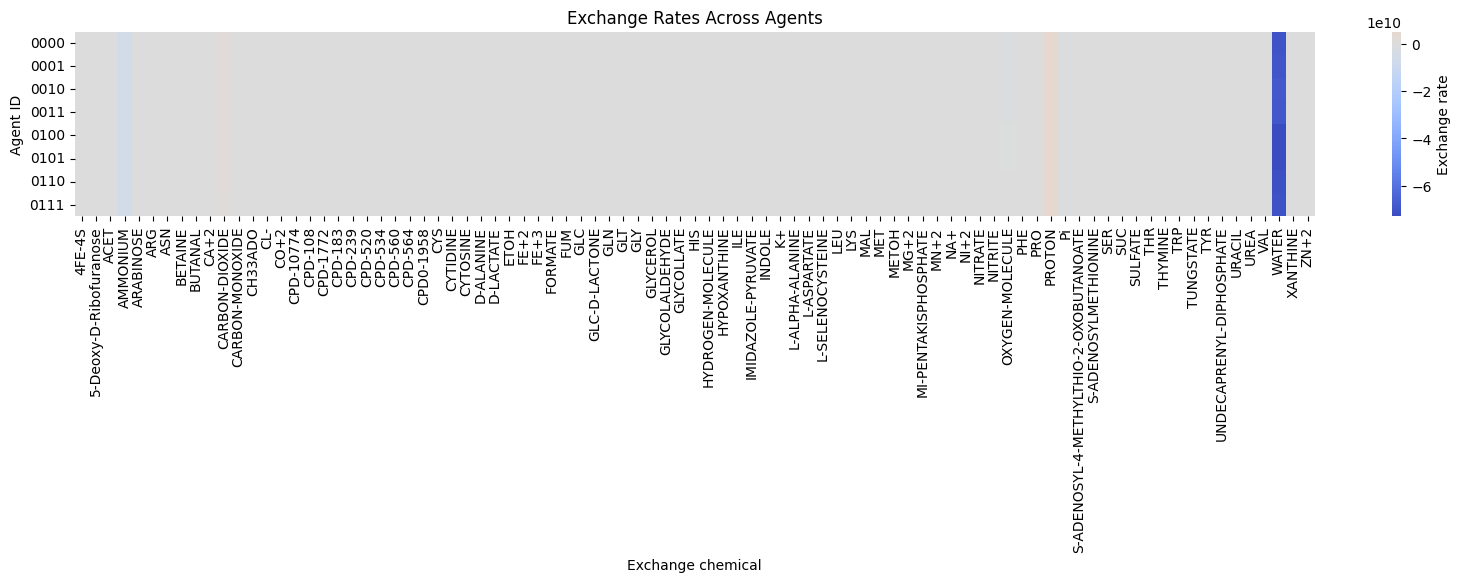

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Build DataFrame: rows=agents, columns=exchange chemicals, values=exchange rates
exchange_data = []
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    row = {'agent_id': agent_id}
    for chem, rate in exchange.items():
        row[chem] = rate
    exchange_data.append(row)

exchange_df = pd.DataFrame(exchange_data)
exchange_df = exchange_df.set_index('agent_id').fillna(0)

# Plot heatmap
plt.figure(figsize=(min(20, 0.5*len(exchange_df.columns)), min(12, 0.3*len(exchange_df))))
sns.heatmap(exchange_df, cmap='coolwarm', center=0, annot=False, cbar_kws={'label': 'Exchange rate'})
plt.xlabel('Exchange chemical')
plt.ylabel('Agent ID')
plt.title('Exchange Rates Across Agents')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1581789/3420995705.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


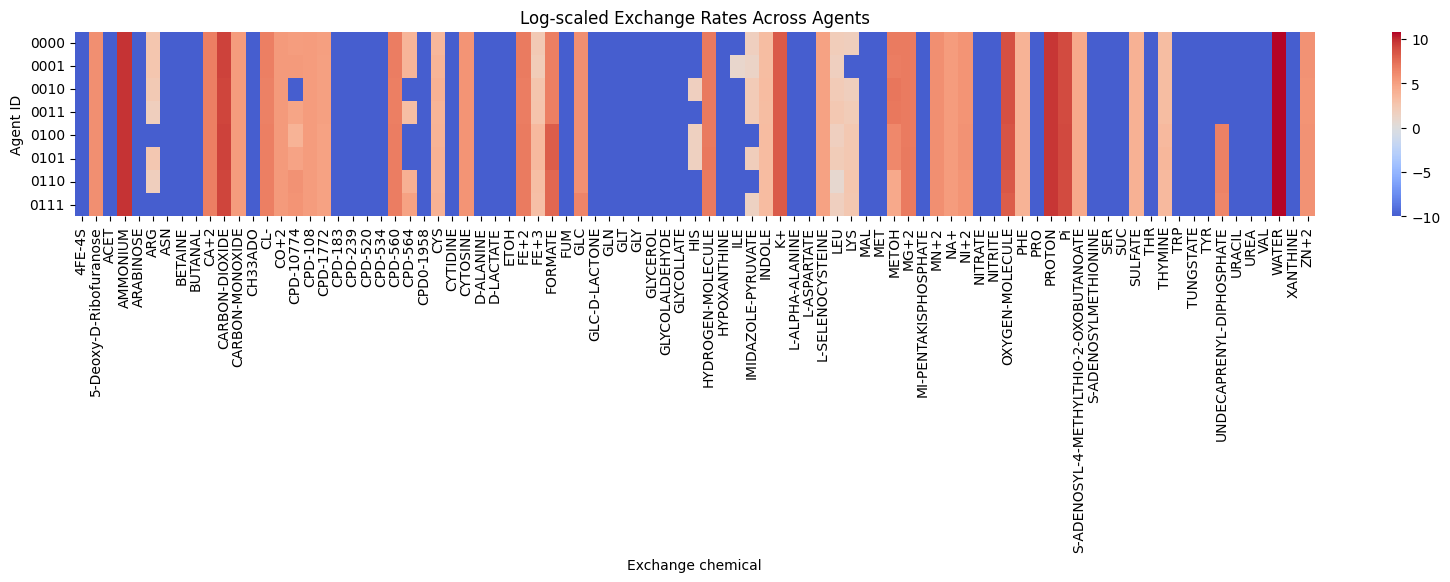

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Build DataFrame: rows=agents, columns=exchange chemicals, values=exchange rates
exchange_data = []
for agent_id in agent_ids:
    env = agents[agent_id].get('environment', {})
    exchange = env.get('exchange', {})
    row = {'agent_id': agent_id}
    for chem, rate in exchange.items():
        row[chem] = rate
    exchange_data.append(row)

exchange_df = pd.DataFrame(exchange_data)
exchange_df = exchange_df.set_index('agent_id').fillna(0)

# Log transform: absolute values only, add small constant to avoid log(0)
e1 = 1e-10
log_exchange_df = np.log10(np.abs(exchange_df) + e1)

# Plot heatmap
plt.figure(figsize=(min(20, 0.5*len(log_exchange_df.columns)), min(12, 0.3*len(log_exchange_df))))
sns.heatmap(log_exchange_df, cmap='coolwarm', center=0, annot=False)
plt.xlabel('Exchange chemical')
plt.ylabel('Agent ID')
plt.title('Log-scaled Exchange Rates Across Agents')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1581789/3316751008.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


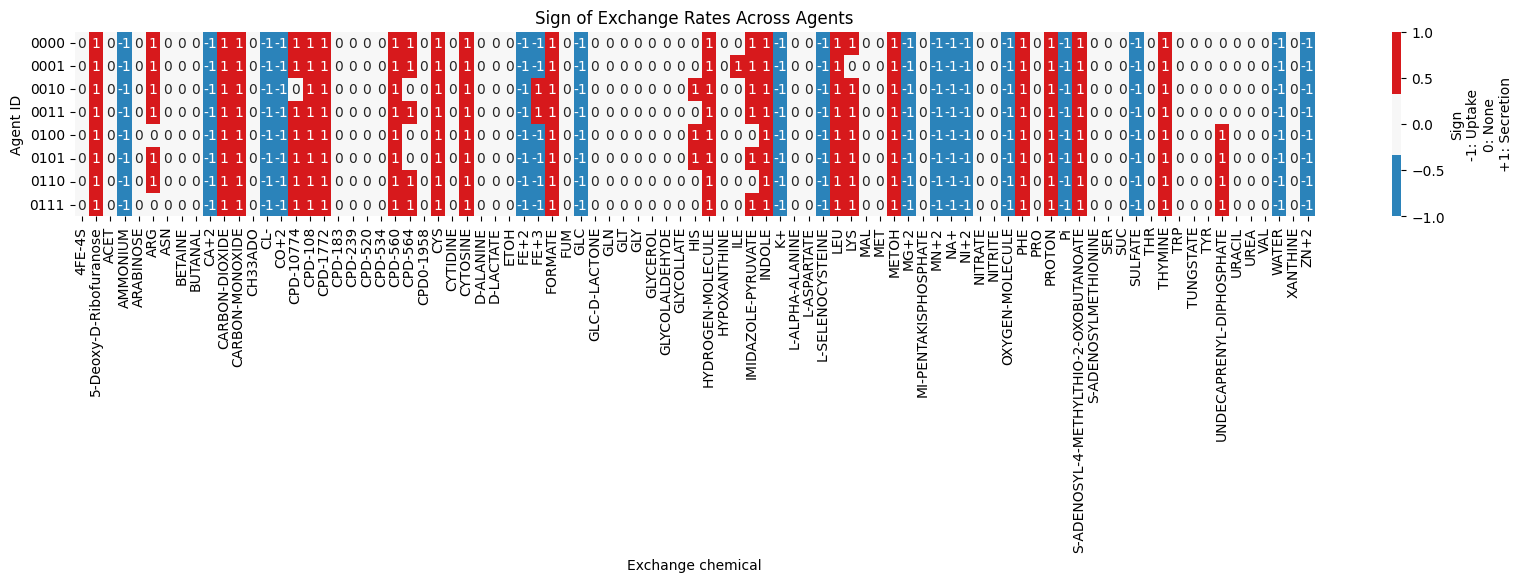

In [8]:
# Plot sign of exchange readings for each agent and chemical
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assumes exchange_df is defined: rows=agent_id, columns=chemicals
# If not, recreate exchange_df from your data as in previous cells

# Compute sign matrix: -1 (uptake), 0 (none), +1 (secretion)
sign_df = np.sign(exchange_df)

plt.figure(figsize=(min(20, 0.5*len(sign_df.columns)), min(12, 0.3*len(sign_df))))
sns.heatmap(sign_df, cmap=sns.color_palette(["#2b83ba", "#f7f7f7", "#d7191c"], as_cmap=True), center=0, annot=True, fmt="d",
            cbar_kws={'label': 'Sign\n-1: Uptake\n0: None\n+1: Secretion'})
plt.xlabel('Exchange chemical')
plt.ylabel('Agent ID')
plt.title('Sign of Exchange Rates Across Agents')
plt.tight_layout()
plt.show()

In [9]:
# Show first 5 zero exchange readings (agent, chemical, value)
import pandas as pd

# Find zero entries in exchange_df
zero_entries = []
for agent in exchange_df.index:
    for chem in exchange_df.columns:
        if exchange_df.loc[agent, chem] == 0:
            zero_entries.append((agent, chem, 0))
            if len(zero_entries) == 5:
                break
    if len(zero_entries) == 5:
        break

# Display
print("First 5 zero exchange readings:")
for entry in zero_entries:
    print(f"Agent: {entry[0]}, Chemical: {entry[1]}, Value: {entry[2]}")

First 5 zero exchange readings:
Agent: 0000, Chemical: 4FE-4S, Value: 0
Agent: 0000, Chemical: ACET, Value: 0
Agent: 0000, Chemical: ARABINOSE, Value: 0
Agent: 0000, Chemical: ASN, Value: 0
Agent: 0000, Chemical: BETAINE, Value: 0


/tmp/ipykernel_1581789/1856500740.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


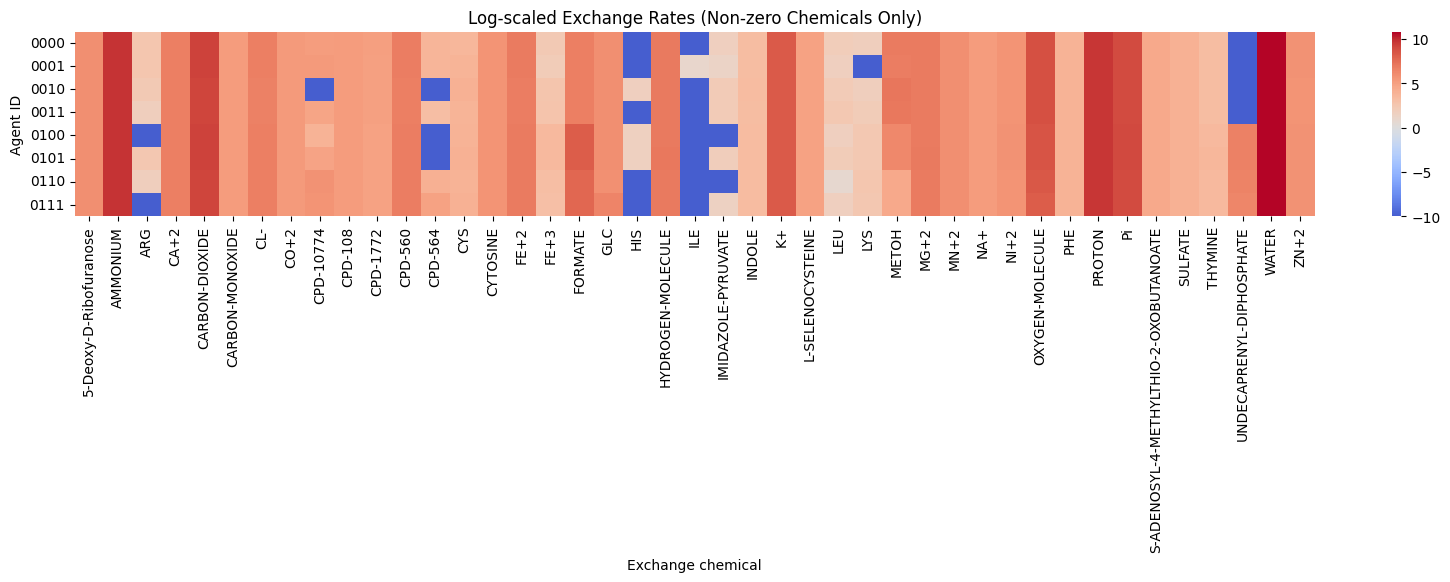

In [10]:
# Plot log-scaled heatmap for chemicals with at least one non-zero value
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Filter columns (chemicals) with at least one non-zero value
nonzero_chems = exchange_df.columns[(exchange_df != 0).any(axis=0)]
filtered_df = exchange_df[nonzero_chems]

# Log transform: absolute values only, add small constant to avoid log(0)
e1 = 1e-10
log_filtered_df = np.log10(np.abs(filtered_df) + e1)

plt.figure(figsize=(min(20, 0.5*len(log_filtered_df.columns)), min(12, 0.3*len(log_filtered_df))))
sns.heatmap(log_filtered_df, cmap='coolwarm', center=0, annot=False)
plt.xlabel('Exchange chemical')
plt.ylabel('Agent ID')
plt.title('Log-scaled Exchange Rates (Non-zero Chemicals Only)')
plt.tight_layout()
plt.show()

### Extract exchange rates

In [ ]:
from pathlib import Path
import re

import pandas as pd

project_name = "baseline_2gen_seed_0_colony_t6000"

def normalize_exchange_name(name):
    return re.sub(r"\[.*?\]", "", str(name)).strip()

# Build wide matrix first: rows=agents, columns=chemicals, values=exchange rates
exchange_data = []
for agent_id in agent_ids:
    env = agents[agent_id].get("environment", {})
    exchange = env.get("exchange", {})

    row = {"agent_id": agent_id}
    for chem, rate in exchange.items():
        row[normalize_exchange_name(chem)] = rate
    exchange_data.append(row)

exchange_df = pd.DataFrame(exchange_data).set_index("agent_id").fillna(0)

# Summarize by chemical: rows=chemicals
ranked_exchange_df = pd.DataFrame(
    {
        "chemical": exchange_df.columns,
        "mean_exchange_rate": exchange_df.mean(axis=0).values,
        "mean_abs_exchange_rate": exchange_df.abs().mean(axis=0).values,
        "max_exchange_rate": exchange_df.max(axis=0).values,
        "min_exchange_rate": exchange_df.min(axis=0).values,
        "max_abs_exchange_rate": exchange_df.abs().max(axis=0).values,
    }
).sort_values(
    by="max_abs_exchange_rate",
    ascending=False,
    ignore_index=True,
)

display(ranked_exchange_df)
print("Shape:", ranked_exchange_df.shape)

out_path = Path(
    "/user/home/il22158/work/vEcoli/reading/results/colony/"
    f"ranked_external_exchange__{project_name}.csv"
)
out_path.parent.mkdir(parents=True, exist_ok=True)
ranked_exchange_df.to_csv(out_path, index=False)

print(f"Saved ranked exchange summary: {out_path}")

,chemical,mean_exchange_rate,mean_abs_exchange_rate,max_exchange_rate,min_exchange_rate,max_abs_exchange_rate
0,WATER,-4.732753e+10,4.732753e+10,-46653325381,-47946468814,47946468814
1,AMMONIUM,-4.115869e+09,4.115869e+09,-4075870702,-4149945034,4149945034
2,PROTON,3.471591e+09,3.471591e+09,3493226680,3445322140,3493226680
3,CARBON-DIOXIDE,1.048475e+09,1.048475e+09,1091144721,997691067,1091144721
4,Pi,-6.368939e+08,6.368939e+08,-630611371,-642199447,642199447
...,...,...,...,...,...,...
82,TYR,0.000000e+00,0.000000e+00,0,0,0
83,UREA,0.000000e+00,0.000000e+00,0,0,0
84,URACIL,0.000000e+00,0.000000e+00,0,0,0
85,VAL,0.000000e+00,0.000000e+00,0,0,0


Shape: (87, 6)
Saved ranked exchange summary: /user/home/il22158/work/vEcoli/reading/results/colony/ranked_external_exchange__baseline_2gen_seed_0_colony_t6000.csv


In [ ]:
import json
import math
import re

UNIT_RE = re.compile(r"^!units\[(.+?)\s+([^\]]+)\]$", re.IGNORECASE)

def parse_units_token(raw):
    """
    raw: e.g. '!units[0.987 millimolar]' or '!units[inf millimolar]'
    returns dict with value, unit, is_inf, is_units_token
    """
    if not isinstance(raw, str):
        return {"value": raw, "unit": None, "is_inf": False, "is_units_token": False}

    m = UNIT_RE.match(raw.strip())
    if not m:
        return {"value": raw, "unit": None, "is_inf": False, "is_units_token": False}

    val_str, unit = m.group(1).strip(), m.group(2).strip()
    is_inf = val_str.lower() in {"inf", "+inf", "infinity", "+infinity", "∞"}

    if is_inf:
        value = math.inf
    else:
        value = float(val_str)

    return {"value": value, "unit": unit, "is_inf": is_inf, "is_units_token": True}


# Example: read from colony JSON and mark infinite-availability entities
with open("/user/home/il22158/work/vEcoli/data/baseline_2gen_seed_0_colony_t6000.json", "r") as f:
    data = json.load(f)

agents = data["agents"]
inf_entities = set()

for agent_id, agent in agents.items():
    ext = agent.get("boundary", {}).get("external", {})
    for mol, raw in ext.items():
        parsed = parse_units_token(raw)
        if parsed["is_inf"] and parsed["unit"].lower() == "millimolar":
            inf_entities.add(mol)

print("Inf-available molecules:", sorted(inf_entities))

# Later comparison: exclude these
# filtered_df = df[~df["chemical"].isin(inf_entities)]

Inf-available molecules: ['CARBON-DIOXIDE', 'CO+2', 'FE+2', 'L-SELENOCYSTEINE', 'MN+2', 'NI+2', 'OXYGEN-MOLECULE', 'WATER', 'ZN+2']


In [ ]:
out_dir = Path("/user/home/il22158/work/vEcoli/reading/results/colony")
file_name = f"inf_available_chemicals__{project_name}.csv"
out_path = out_dir / file_name
pd.DataFrame({"chemical": sorted(inf_entities)}).to_csv(out_path, index=False)
print(f"Saved inf-available chemicals: {out_path}")

Saved inf-available chemicals: /user/home/il22158/work/vEcoli/reading/results/colony/inf_available_chemicals__baseline_2gen_seed_0_colony_t6000.csv


In [ ]:
import json

json_path = "/user/home/il22158/work/vEcoli/data/baseline_2gen_seed_0_colony_t6000.json"

with open(json_path, "r") as f:
    data = json.load(f)

agents = data["agents"]

# Print mmol_to_counts for each agent (raw value from JSON)
for agent_id in sorted(agents):
    mmol_to_counts = agents[agent_id].get("boundary", {}).get("mmol_to_counts")
    print(agent_id, mmol_to_counts)

000 !units[771553.3883459674 / millimolar]
001 !units[762474.9073928331 / millimolar]
010 !units[772383.1576104428 / millimolar]
011 !units[776935.0041671057 / millimolar]


Clarification:

In the code, mmol_to_counts is defined as Avogadro × volume, then converted to L/mmol, not as a concentration value itself: derive_globals.py:82, derive_globals.py:121, derive_globals.py:139-144.

In the exchange process, they explicitly say concentrations are mmol/L, then multiply by mmol_to_counts to get counts: exchange.py:57-64.

In [ ]:
from pathlib import Path
import re
import pandas as pd

project_name = "baseline_2gen_seed_0_colony_t6000"


def normalize_exchange_name(name):
    return re.sub(r"\[.*?\]", "", str(name)).strip()


def parse_units_number(value):
    # Works for strings like "!units[771553.3883459674 / millimolar]"
    if isinstance(value, str):
        m = re.search(r"\[([+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)", value)
        if m:
            return float(m.group(1))
    return float(value)


def counts_to_mM(delta_counts, mmol_to_counts_raw):
    mmol_to_counts = parse_units_number(mmol_to_counts_raw)  # counts per mM
    if mmol_to_counts <= 0:
        return pd.NA
    return delta_counts / mmol_to_counts  # mM per step


# Build wide matrix first: rows=agents, columns=chemicals, values=exchange (mM per step)
exchange_data = []
for agent_id in agent_ids:
    agent = agents[agent_id]
    env = agent.get("environment", {})
    boundary = agent.get("boundary", {})
    exchange = env.get("exchange", {})

    mmol_to_counts_raw = boundary.get("mmol_to_counts")

    row = {"agent_id": agent_id}
    for chem, rate in exchange.items():
        row[normalize_exchange_name(chem)] = counts_to_mM(rate, mmol_to_counts_raw)
    exchange_data.append(row)

exchange_df = pd.DataFrame(exchange_data).set_index("agent_id").fillna(0)

# Summarize by chemical: rows=chemicals
ranked_exchange_df = pd.DataFrame(
    {
        "chemical": exchange_df.columns,
        "mean_exchange": exchange_df.mean(axis=0).values,
        "mean_abs_exchange": exchange_df.abs().mean(axis=0).values,
        "max_exchange": exchange_df.max(axis=0).values,
        "min_exchange": exchange_df.min(axis=0).values,
        "max_abs_exchange": exchange_df.abs().max(axis=0).values,
        "unit": "mM",
    }
).sort_values(
    by="max_abs_exchange",
    ascending=False,
    ignore_index=True,
)

display(ranked_exchange_df)
print("Shape:", ranked_exchange_df.shape)

out_path = Path(
    "/user/home/il22158/work/vEcoli/reading/results/colony/"
    f"ranked_external_exchange__{project_name}__mM.csv"
)
out_path.parent.mkdir(parents=True, exist_ok=True)
ranked_exchange_df.to_csv(out_path, index=False)

print(f"Saved ranked exchange summary: {out_path}")

,chemical,mean_exchange,mean_abs_exchange,max_exchange,min_exchange,max_abs_exchange,unit
0,WATER,-61396.338986,61396.338986,-60893.162160,-61793.161915,61793.161915,mM
1,AMMONIUM,-5339.490276,5339.490276,-5303.856184,-5367.093398,5367.093398,mM
2,PROTON,4503.720369,4503.720369,4518.603965,4484.076374,4518.603965,mM
3,CARBON-DIOXIDE,1360.462602,1360.462602,1414.218040,1284.137105,1414.218040,mM
4,Pi,-826.237690,826.237690,-819.899961,-831.451904,831.451904,mM
...,...,...,...,...,...,...,...
82,TYR,0.000000,0.000000,0.000000,0.000000,0.000000,mM
83,UREA,0.000000,0.000000,0.000000,0.000000,0.000000,mM
84,URACIL,0.000000,0.000000,0.000000,0.000000,0.000000,mM
85,VAL,0.000000,0.000000,0.000000,0.000000,0.000000,mM


Shape: (87, 7)
Saved ranked exchange summary: /user/home/il22158/work/vEcoli/reading/results/colony/ranked_external_exchange__baseline_2gen_seed_0_colony_t6000__mM.csv


gDCW means grams of Dry Cell Weight: the cell mass excluding water.

So mmol/gDCW/h means “millimoles exchanged per gram of dry biomass per hour,” which normalizes flux by cell size.

### Bar plot

<Figure size 2800x700 with 0 Axes>

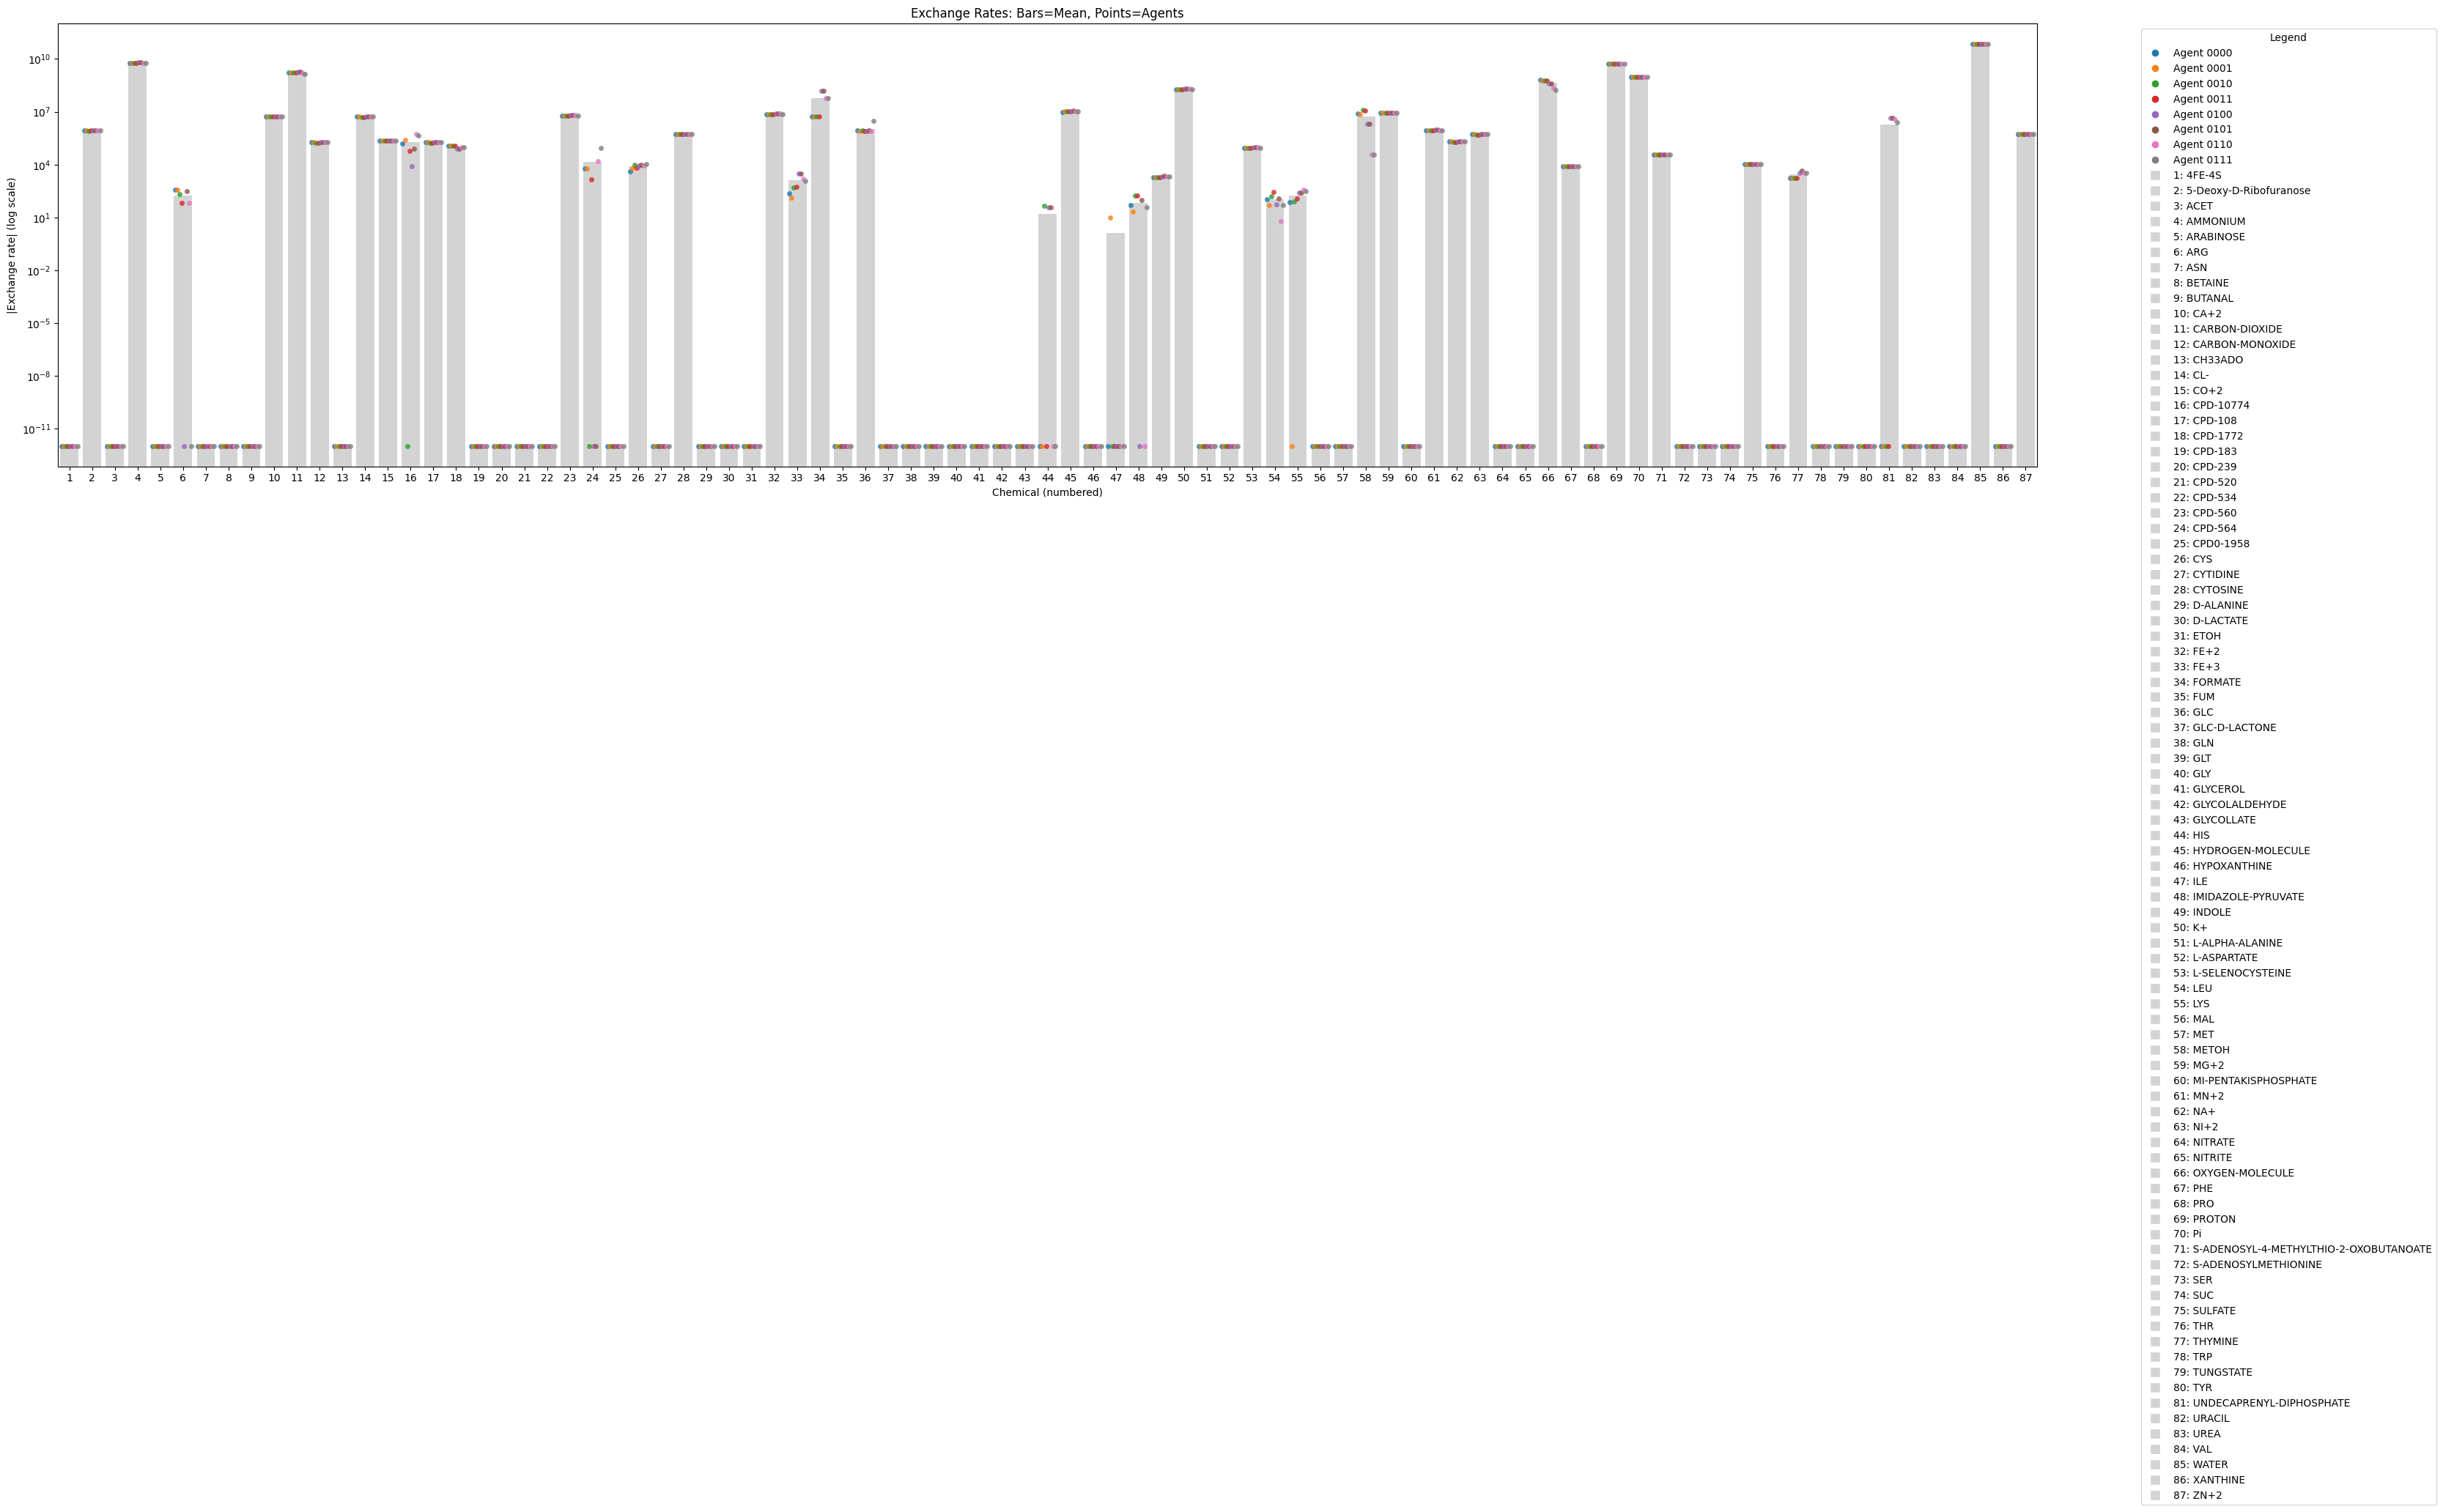

In [ ]:
# Plot: Each chemical as a bar group, each agent as a point (dot strip) on log scale
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Recreate df_melt for this cell
# Assumes exchange_df is defined: rows=agent_id, columns=chemicals
# If not, you can create exchange_df from your data as in previous cells

df_melt = exchange_df.reset_index().melt(id_vars='agent_id', var_name='chemical', value_name='rate')

# Widen the figure for better x-axis spacing
fig_width = max(12, min(2 + len(exchange_df.columns) * 2.2, 28))
plt.figure(figsize=(fig_width, 7))
df_melt['abs_rate'] = np.abs(df_melt['rate']) + 1e-12
mean_rates = df_melt.groupby('chemical')['abs_rate'].mean().reset_index()

# Assign numbers to chemicals
chemical_labels = list(mean_rates['chemical'])
chemical_numbers = {chem: i+1 for i, chem in enumerate(chemical_labels)}
df_melt['chem_num'] = df_melt['chemical'].map(chemical_numbers)
mean_rates['chem_num'] = mean_rates['chemical'].map(chemical_numbers)

# Plot using chemical numbers as x
plt.figure(figsize=(fig_width, 7))
sns.barplot(data=mean_rates, x='chem_num', y='abs_rate', color='lightgray', zorder=1)
# Use hue for agent_id to color dots by agent
sns.stripplot(data=df_melt, x='chem_num', y='abs_rate', hue='agent_id',
              dodge=True, jitter=True, marker='o', alpha=0.8, zorder=2, legend=False)

plt.yscale('log')
plt.xlabel('Chemical (numbered)')
plt.ylabel('|Exchange rate| (log scale)')
plt.title('Exchange Rates: Bars=Mean, Points=Agents')
plt.tight_layout()

# Set x-ticks to numbers and show mapping in legend
plt.xticks(ticks=range(len(chemical_labels)), labels=[f"{i+1}" for i in range(len(chemical_labels))])

# Build legend: mapping number to chemical and agent colors
# Get agent colors from seaborn palette
unique_agents = sorted(df_melt['agent_id'].unique())
palette = sns.color_palette(n_colors=len(unique_agents))
agent_color_map = dict(zip(unique_agents, palette))

legend_elements = [
    *[Line2D([0], [0], marker='o', color='w', label=f"Agent {agent}", markerfacecolor=agent_color_map[agent], markersize=8)
      for agent in unique_agents],
    *[Line2D([0], [0], marker='s', color='w', label=f"{i+1}: {chem}", markerfacecolor='lightgray', markersize=10)
      for i, chem in enumerate(chemical_labels)]
]
plt.legend(handles=legend_elements, title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

- Definition:
"Exchange reading" refers to the process of tracking the movement of molecules between the cell and its environment, typically implemented as "exchange reactions" in metabolic models. In the codebase, this is handled by the Exchange process, which updates molecule counts based on uptake and secretion rates.

- Directionality:
The convention in the code (see modular_fba.py) is that exchange fluxes are defined as pointing out of the system (cell), even though exchanges can represent both import (uptake) and export (secretion).
The sign of the exchange value is not always positive:
Uptake (import) is typically represented as a negative flux (into the cell).
Secretion (export) is positive (out of the cell).

- Summary:

1. Exchange readings can be positive or negative, depending on whether the molecule is being taken up or secreted.
2. The codebase uses negative values for uptake and positive for secretion, following standard metabolic modeling conventions.

- References:

1. exchange.py: Implements molecule movement with uptake and secretion rates.
2. modular_fba.py: Exchange reactions are set as pointing out of the system, but can represent both directions.

# Colony Simulation Basics

## Estimate cycle time from single-cell

Reference from previous study:
- Baseline wrapper with generation hints (still hard-coded times): tet_amp_sim.py:77-83 comments 26000 ≈ 8th division round and sets save_times [11550, 23100].

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd

# Variant-0 baseline timeseries
ts_path = Path('/user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet')
if not ts_path.exists():
    raise FileNotFoundError(ts_path)

df = pd.read_parquet(ts_path)
if 'project' in df.columns:
    df = df[df['project'].astype(str).str.contains('all_media_conditions1', na=False)]
df = df[df['variant'] == 0].copy()

time_col = 'time'
mass_col = 'listeners__mass__dry_mass'
mu_col = 'listeners__mass__instantaneous_growth_rate'
df = df[[time_col, mass_col, mu_col]].dropna()
df = df[df[mass_col] > 0].sort_values(time_col).reset_index(drop=True)

# If multiple rows per time exist, aggregate first (prevents random drop_duplicates artifacts)
df = df.groupby(time_col, as_index=False).agg({mass_col: 'median', mu_col: 'median'})

# Robust μ-based estimate (works with division sawtooth)
mu_pos = df.loc[df[mu_col] > 0, mu_col]
tau_mu_sec = np.log(2) / mu_pos.median()

# Segment-wise mass fits between division events (mass drops)
mass = df[mass_col].to_numpy()
time = df[time_col].to_numpy()
drop_frac = np.diff(mass) / mass[:-1]
break_idx = np.where(drop_frac < -0.2)[0] + 1  # division-like drops >20%
starts = np.r_[0, break_idx]
ends = np.r_[break_idx, len(df)]

taus_mass = []
for s, e in zip(starts, ends):
    seg_t = time[s:e]
    seg_m = mass[s:e]
    if len(seg_t) < 8:
        continue
    if seg_t[-1] - seg_t[0] < 600:  # require >=10 min segment
        continue
    k, _ = np.polyfit(seg_t, np.log(seg_m), 1)
    if k > 0:
        taus_mass.append(np.log(2) / k)

tau_mass_sec = float(np.median(taus_mass)) if taus_mass else np.nan

print(f'Using file: {ts_path}')
print(f'Variant 0 aggregated points: {len(df)}, time span: {time.min():.1f} to {time.max():.1f} s')
print(f'Doubling time from median positive mu: {tau_mu_sec:.1f} s ({tau_mu_sec/60:.2f} min)')
if np.isfinite(tau_mass_sec):
    print(f'Doubling time from segment-wise log-mass fits (median): {tau_mass_sec:.1f} s ({tau_mass_sec/60:.2f} min)')
    tau_use = tau_mass_sec
else:
    print('Segment-wise mass fit unavailable; using mu-based estimate.')
    tau_use = tau_mu_sec

n_generations = 4
save_times = [int(round(i * tau_use)) for i in range(1, n_generations + 1)]
print(f'Suggested save_times for {n_generations} generations: {save_times}')

Using file: /user/home/il22158/work/vEcoli/reading/results/growth_rate/growth_rate_timeseries_seed100_all.parquet
Variant 0 aggregated points: 1205, time span: 0.0 to 24009.0 s
Doubling time from median positive mu: 2909.8 s (48.50 min)
Doubling time from segment-wise log-mass fits (median): 2867.3 s (47.79 min)
Suggested save_times for 4 generations: [2867, 5735, 8602, 11469]


****Segment-wise log-mass fit****
- Segment-wise means the time step is not 1 sec so we don't assume each data point is 1 sec apart from each other.
- A single global fit of `log(dry_mass)` over multi-generation data is biased because division creates sawtooth drops in mass.
- We first detect division-like breakpoints where relative mass drop is `< -0.2` between adjacent points.
- Then we fit `log(M)=a+kt` separately on each growth segment (minimum length and duration filters).
- For each valid segment, doubling time is `tau = ln(2)/k` (only positive `k`).
- Final mass-based estimate is the median of segment-level `tau` values, which is robust to noisy/atypical segments.
- This gives a biologically consistent estimate and matches the independent `mu`-based estimate much better than a global fit.

## Colony Simulation Setup (from `doc/experiments.rst`)

### Inherting previous simulation

- Resuming from `initial_colony_file` loads the saved state, but simulation clock does **not** auto-inherit from filename `_tXXXX`.
> `ecoli/experiments/ecoli_engine_process.py:375-377` loads `data/{initial_colony_file}.json`, while `:386` uses `_tXXXX` only for seed offset logic.

- Global time starts from `start_time` (default `0`) unless explicitly set.
 > `ecoli/experiments/ecoli_engine_process.py:369` sets `start_time = config.get('start_time', 0)`; `:478` passes `initial_global_time=config.get('start_time', 0.0)` to Engine.

- The docs confirm `initial_global_time` is the explicit control, and hard stop is `initial_global_time + max_duration`.
 > `doc/experiments.rst:171-178`

- Practical implication: restarting from `..._t6000` with no `start_time` still starts at global time 0 in the new run metadata/timeline.

****Code check + proposed routine****

- `initial_colony_file` restores states, but **time does not auto-inherit** from `_tXXXX` unless `start_time` is set.
- `max_duration` is segment runtime (seconds), not generation-aware.
- For continuity, set `start_time` to previous snapshot time.

**Routine for next inherited run**
1. Parse previous snapshot time (e.g., `baseline_2gen_seed_0_colony_t6000` → `6000`).
2. Set in config: `initial_colony_file`, `start_time=6000`.
3. Set `max_duration` to extra runtime you want (not absolute end time).
4. Set `save_times` as times within this segment.
5. Optional: if you need absolute time in output names, patch naming logic (current filename uses segment `save_times`).

**Example**
```json
{
  "initial_colony_file": "baseline_2gen_seed_0_colony_t6000",
  "start_time": 6000,
  "max_duration": 3000,
  "save": true,
  "save_times": [3000]
}
```

****Clarification about start_time and save_times:****

save_times is treated as segment-local times:
- validated against max_duration: ecoli_engine_process.py:243-247
- used to compute update intervals (time_to_next_save): ecoli_engine_process.py:249-254
- used directly in output filename _t{time_elapsed}: ecoli_engine_process.py:256-294

start_time is used to set global simulation clock offset:
- read into base config: ecoli_engine_process.py:369
- pass to Engine as initial_global_time: ecoli_engine_process.py:47

So counter-intuitively—if you manually set start_time, it is considered for global time progression; it does not change how save_times is interpreted or validated.

### Basic Configuration Parameters

**Key Module**: `ecoli.experiments.ecoli_engine_process` - designed for multi-cell colonies in shared spatial environments.

**How it works**: Each cell is wrapped in an `EngineProcess` that can be run in parallel and interact with other cells in a shared environment.

**Colony-specific config options**:
- `engine_process_reports`: Paths inside each cell to save (e.g., `["bulk"]`, `["boundary"]`)
- `emit_paths`: Paths in outer simulation to save (e.g., cell locations)
- `parallel`: Run cells in parallel for speedup

**Useful options for colony**:
- `save` & `save_times`: Create colony state snapshots (e.g., 16-cell state)
- `colony_save_prefix`: Prefix for saved state files
- `initial_colony_file`: Start from a saved colony state
- `spatial_environment: true` & `spatial_environment_config`: Enable shared spatial environment

**Example config** (see `configs/spatial.json`):
```json
{
    "spatial_environment": true,
    "spatial_environment_config": {
        "multibody": {"bounds": ["50 μm", "50 μm"]},
        "reaction_diffusion": {"molecules": ["GLC"], ...}
    }
}
```

**Note**: Current `workflow.py` has `generate_colony()` as a stub (returns empty lists) - colony simulations are run via `ecoli_engine_process.py` directly, not through the Nextflow workflow.

## How to Run Colony Simulation

**Two scripts available:**

| Script | Purpose | Use When |
|--------|---------|----------|
| `ecoli_engine_process.py` | Core engine | Clean baseline, custom experiments |
| `tet_amp_sim.py` | Wrapper + antibiotic setup | Antibiotic experiments |

**Option 1: Clean baseline** (recommended):
```bash
python ecoli/experiments/ecoli_engine_process.py --config configs/colony_customised.json
```

**Option 2: Quick test via tet_amp_sim** (has antibiotic overhead):
```bash
python ecoli/experiments/tet_amp_sim.py --baseline --seed 0 --local
```

**`tet_amp_sim.py --baseline` still adds:**
- Extra processes: `ecoli-cell-wall`, `ecoli-pbp-binding`, `ecoli-lysis-initiation`, `murein-division`
- Antibiotic bulk molecules (tetracycline, ampicillin, marR-tet, etc.) with count=0
- MarA/MarR TF binding sites to all promoters

**CLI flags** (`tet_amp_sim.py`): `-b` baseline, `-s` seed, `-l` local, `-r` runtime, `-i` initial_colony_file

Note: The CellWall process (in cell_wall.py) is a coarse-grained model for predicting cell wall cracking and lysis. It:

Simulates peptidoglycan (murein) lattice structure
Detects "holes" in the lattice that could lead to membrane bulging
Triggers lysis when holes exceed a critical radius

## Colony Simulation Output

**Where files are saved:**
- Snapshots: `data/{colony_save_prefix}_seed_{seed}_colony_t{time}.json`
- Example: `data/glc_combined_seed_0_colony_t11550.json`

**Data saved in each snapshot:**
- Full colony state (all agents/cells)
- Per-cell internal state: `bulk`, `unique`, environment exchange data
- Bulk/unique dtypes for proper reconstruction
- Cell boundary & spatial info (if `spatial_environment: true`)

**Customizing snapshots (more than default 2):**
```python
config["save"] = True
config["save_times"] = [5000, 10000, 15000, 20000, 25000]  # 5 snapshots
```
- `save_times` is a list of simulation times (in seconds) at which to save
- Default baseline: `[11550, 23100]` (~4th and ~7th generation)
- Times must be ≤ `max_duration`

### Trial Run Design

```bash
python ecoli/experiments/ecoli_engine_process.py --config configs/colony_baseline_test.json
```

#### Trial 1
Implemented in: `colony_baseline_test.json`

**Goal**: 2 generations (1 cell → 4 cells), save parquet for each cell, save final state for later continuation.

```json
{
    "inherit_from": ["spatial.json"],
    "description": "Test: 2 generations (4 cells), save parquet per cell, save final state",
    
    "seed": 0,
    "sim_data_path": "out/all_media_conditions1/parca/kb/simData.cPickle",
    
    "emitter": "timeseries",
    "emitter_arg": {},
    
    "inner_emitter": "parquet",
    
    "max_duration": 6000,
    
    "save": true,
    "save_times": [6000],
    "colony_save_prefix": "baseline_2gen",
    
    "parallel": false,
    
    "engine_process_reports": [
        ["boundary"],
        ["bulk"],
        ["listeners"],
        ["environment", "exchange"]
    ]
}
```

**Key Options Explained:**

| Option | Value | Reason |
|--------|-------|--------|
| `inherit_from` | `["spatial.json"]` | Gets spatial environment config + ecoli-shape process |
| `sim_data_path` | existing parca output | Required! Points to pre-computed simulation parameters |
| `emitter` | `"timeseries"` | Outer sim uses timeseries (avoids pint.Quantity serialization bug with parquet) |
| `inner_emitter` | `"parquet"` | Each cell's data saved to parquet files |
| `max_duration` | `6000` | ~100 min, enough for 2 generations (~44 min each on minimal) |
| `save` + `save_times` | `true`, `[6000]` | Save colony state at end for later continuation |
| `colony_save_prefix` | `"baseline_2gen"` | Output: `data/baseline_2gen_seed_{seed}_colony_t6000.json` |
| `engine_process_reports` | 4 paths | What gets emitted per cell |

**Known Issue**: Parquet emitter cannot serialize `pint.Quantity` in spatial_environment_config. Workaround: use `timeseries` for outer emitter, `parquet` for inner (per-cell) emitter.

**Output Files:**
- **Parquet**: `out/[timestamp_id]/.../*.parquet` - Per-cell time-series data
- **State JSON**: `data/baseline_2gen_seed_0_colony_t6000.json` - Full colony state for restart

**Run Command:**
```bash
python ecoli/experiments/ecoli_engine_process.py --config configs/colony_baseline_test.json
```

**To Continue from Saved State:**
```json
{
    "inherit_from": ["spatial.json"],
    "initial_state_file": "data/baseline_2gen_seed_0_colony_t6000.json",
    "max_duration": 12000
}
```